# Import, config and load data

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import *

from darts import TimeSeries
from darts.dataprocessing.transformers import WindowTransformer, StaticCovariatesTransformer

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

import os
# -------------------- CONFIG --------------------
DATA_FOLDER       = "./data"
FIXED_DATA_PATH   = construct_path(DATA_FOLDER, "fixed")
DATASET_PATH      = construct_path(DATA_FOLDER, "dataset")

TARGET_RAW_EVENT_CLASSIFIER        = "act_drone_strike_on_ua"          # count target
TARGET_EVENT_CLASSIFIER            = "act_drone_strike_on_ua_binary"   # binary target
TARGET_REGRESSOR = TARGET_RAW_EVENT_CLASSIFIER

# Forecasting setup
OUTPUT_CHUNK_LEN  = 7      # how many days ahead each model predicts in one shot
INPUT_LAGS        = 7      # how many past days of the target the model sees
MULTI_MODELS      = True   # direct strategy: one sub-model per horizon step

# CV / split
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.10, 0.20   # enforced by split_series_list
CV_STRIDE                       = 1                   # For final evaluation No weekly stride, new forecast everyday


available_threads = get_available_threads()
print(f'CPU count: {available_threads}')

RANDOM_STATE      = 42
np.random.seed(RANDOM_STATE)

CPU count: 4


In [2]:
regions,master_timeseries,regions_activity = \
    load_data(data_path=FIXED_DATA_PATH,dataset_path=DATASET_PATH)

master_timeseries shape: (847, 1622)
regions: 25  -  ['cherkasy', 'chernihiv', 'chernivtsi', 'dnipropetrovsk', 'donetsk'] ...
start: 2022-09-28 00:00:00 end: 2025-01-21 00:00:00


In [3]:
# For regressor
for_global_REGRESSOR, global_weather_columns = get_engineered_features(
    master_timeseries=master_timeseries,
    data_path=FIXED_DATA_PATH,
    target_col=TARGET_REGRESSOR,
    regions=regions,
    regions_activity=regions_activity,
    binarize_target=False
)
#For event_classifier
for_global_EVENT_CLASSIFIER, _ = get_engineered_features(
    master_timeseries=master_timeseries,
    data_path=FIXED_DATA_PATH,
    target_col=TARGET_EVENT_CLASSIFIER, 
    regions=regions,
    regions_activity=regions_activity,
    binarize_target=True,
    target_raw_col=TARGET_RAW_EVENT_CLASSIFIER
)

Shape after feature engineering: (16940, 115)
Target mean: 0.394
Shape after feature engineering: (16940, 115)
Target positive rate: 0.144


In [4]:
# For event_classifier
holiday_cols_c, future_covariates_c, exclude_cols_c, past_covariates_c = split_future_and_past_cov(for_global_EVENT_CLASSIFIER,global_weather_columns,TARGET_EVENT_CLASSIFIER)
# For regressor
holiday_cols_r, future_covariates_r, exclude_cols_r, past_covariates_r = split_future_and_past_cov(for_global_REGRESSOR,global_weather_columns,TARGET_REGRESSOR)

# future covariates : 27
# past covariates   : 85
# future covariates : 27
# past covariates   : 85


### Building timeseries objects

In [5]:
# For event_classifier
target_series_list_c, past_covs_list_c,future_covs_list_c =build_ts_and_apply_window_transformer(
                                            for_global_EVENT_CLASSIFIER,
                                            TARGET_EVENT_CLASSIFIER,
                                            past_covariates_c,
                                            future_covariates_c,
                                            ed_alpha=halflife_to_alpha(7)
                                            )
# For regressor
target_series_list_r, past_covs_list_r,future_covs_list_r =build_ts_and_apply_window_transformer(
                                            for_global_REGRESSOR,
                                            TARGET_REGRESSOR,
                                            past_covariates_r,
                                            future_covariates_r,
                                            ed_alpha=halflife_to_alpha(7)
                                            )

Past-cov components: raw=85  transformed=595
Past-cov components: raw=85  transformed=595


In [6]:
# For event_classifier
region_names, train_target_c, val_target_c, test_target_c, full_past_covs_c, full_fut_covs_c, target_for_cv_c, TRAIN_VAL_END,CV_START_VAL =\
      get_covs_and_encodings(target_series_list_c,past_covs_list_c,future_covs_list_c,TRAIN_FRAC,VAL_FRAC)

# For regressor
_, train_target_r, val_target_r, test_target_r, full_past_covs_r, full_fut_covs_r, target_for_cv_r, _,_ =\
      get_covs_and_encodings(target_series_list_r,past_covs_list_r,future_covs_list_r,TRAIN_FRAC,VAL_FRAC)

# regions: 20
train len (region 0): 593 days
val   len (region 0): 85 days
test  len (region 0): 169 days  <- untouched until the final evaluation
CV view length       : 676 days (train+val)
CV start on that view: 0.875  -> rolls across the val segment only
# regions: 20
train len (region 0): 593 days
val   len (region 0): 85 days
test  len (region 0): 169 days  <- untouched until the final evaluation
CV view length       : 676 days (train+val)
CV start on that view: 0.875  -> rolls across the val segment only


### Building the classifier and regressors themselves

In [8]:
from darts.models import LightGBMModel,LightGBMClassifierModel,SKLearnClassifierModel,CatBoostModel
from imbens.ensemble import SelfPacedEnsembleClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

COMMON_KWARGS = get_common_kwargs()

# We can use calibration with Venn- ABERS here or use posthoc calibration with platt 
def get_event_classifier(**kwargs):
    DTm_depth = kwargs.get('DTm_depth',5)
    SPE_estm = kwargs.get('SPE_estm',100)
    clf = SelfPacedEnsembleClassifier(
        estimator    = DecisionTreeClassifier(
            max_depth=DTm_depth, 
            random_state=RANDOM_STATE
            ),
        n_estimators = SPE_estm,                
        random_state = RANDOM_STATE,
        n_jobs       = available_threads,
    )

    return SKLearnClassifierModel(model=clf, **COMMON_KWARGS)

def get_count_regressor(**kwargs):
        return CatBoostModel(
            **COMMON_KWARGS,
            loss_function     = "Tweedie:variance_power=1.5",
            boost_from_average= False,
            random_seed       = RANDOM_STATE,
            task_type         = "CPU",
            thread_count = available_threads,
            **kwargs
        )

event_classifier_feature_selection =  LightGBMClassifierModel(
            **COMMON_KWARGS,
            objective         = "binary",
            is_unbalance      = True,
            random_state      = RANDOM_STATE,
        )

regressor_feature_selection = LightGBMModel(
            **COMMON_KWARGS,
            objective         = "poisson",
            random_state      = RANDOM_STATE,
        )



In [9]:
# Train on positive samples only
full_weights = make_positive_only_weights(target_series_list_r)
# For regressor
regressor_feature_selection.fit(
    series            = train_target_r,
    past_covariates   = full_past_covs_r,
    future_covariates =  full_fut_covs_r,
    sample_weight     = [w.slice_intersect(ts) for w, ts in zip(full_weights, train_target_r)],
)


top_100_features_r = get_top_100_from_lgbm(regressor_feature_selection)
top_100_features_dict_r = clean_feature_names(top_100_features_r)

# For classifier
event_classifier_feature_selection.fit(
    series          = train_target_c,
    past_covariates = full_past_covs_c,
    future_covariates = full_fut_covs_c,
)

top_100_features_c = get_top_100_from_lgbm(event_classifier_feature_selection)
top_100_features_dict_c = clean_feature_names(top_100_features_c)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.400703 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 299717
[LightGBM] [Info] Number of data points in the train set: 11460, number of used features: 2097
[LightGBM] [Info] Start training from score 0.665190
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.455811 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 299717
[LightGBM] [Info] Number of data points in the train set: 11460, number of used features: 2097
[LightGBM] [Info] Start training from score 0.667159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.464755 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 299717
[LightGBM] [Info] Number of data points in the train set: 11460, number of used features: 2097
[LightGBM] [Inf

In [10]:
# For classifier
past_covs_list_c   = [subset_safe(ts, top_100_features_dict_c['pastcov_features_base']) for ts in past_covs_list_c]
future_covs_list_c = [subset_safe(ts, top_100_features_dict_c['futcov_features_base'])  for ts in future_covs_list_c]
_, train_target_c, val_target_c, test_target_c, full_past_covs_c, full_fut_covs_c, target_for_cv_c,TRAIN_VAL_END,CV_START_VAL = \
    get_covs_and_encodings(target_series_list_c,past_covs_list_c,future_covs_list_c,TRAIN_FRAC,VAL_FRAC)

# For Regressor
past_covs_list_r   = [subset_safe(ts, top_100_features_dict_r['pastcov_features_base']) for ts in past_covs_list_r]
future_covs_list_r = [subset_safe(ts, top_100_features_dict_r['futcov_features_base'])  for ts in future_covs_list_r]
_, train_target_r, val_target_r, test_target_r, full_past_covs_r, full_fut_covs_r, target_for_cv_r,_,_ = \
    get_covs_and_encodings(target_series_list_r,past_covs_list_r,future_covs_list_r,TRAIN_FRAC,VAL_FRAC)

# regions: 20
train len (region 0): 593 days
val   len (region 0): 85 days
test  len (region 0): 169 days  <- untouched until the final evaluation
CV view length       : 676 days (train+val)
CV start on that view: 0.875  -> rolls across the val segment only
# regions: 20
train len (region 0): 593 days
val   len (region 0): 85 days
test  len (region 0): 169 days  <- untouched until the final evaluation
CV view length       : 676 days (train+val)
CV start on that view: 0.875  -> rolls across the val segment only


# Predictions;
- Probability that event happends (i.e. probabilistic output of classifier) $\hat{\pi}(x) = P(Y > 0 | X)$ 

- The count of the events given that it happends $\hat{\mu}(x) = E(Y | X,Y > 0)$ 

- Final estimate $\hat{E}(Y|X) = \hat{\pi}(x) \cdot \hat{\mu}(x)$ 
- y_pred ($\hat{y} = \hat{E}(Y|X)$)

## Cross-Validation

In [11]:
from sklearn.metrics import r2_score
from src import base_metrics, _scaled_metrics  

def _hurdle_metrics(y_true, y_pred):
    """base_metrics (from src) extended with R²."""
    base = base_metrics(y_true, y_pred)
    y_true_arr = np.asarray(y_true, dtype=float).ravel()
    y_pred_arr = np.clip(np.asarray(y_pred, dtype=float).ravel(), 0.0, None)
    base["R2"] = float(r2_score(y_true_arr, y_pred_arr))
    return base


def evaluate_hurdle_long(long_df, mae_scales, rmse_scales):
    """evaluate_long extended with R². mae_scales/rmse_scales from compute_naive_scales."""
    def _rows_from_groupby(group_cols):
        rows = []
        for keys, sub in long_df.groupby(group_cols):
            row = _hurdle_metrics(sub["y_true"], sub["y_pred"])
            key_map = (
                {group_cols: keys} if isinstance(group_cols, str)
                else dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
            )
            region_key = key_map.get("region")
            if region_key is not None:
                row.update(_scaled_metrics(sub, mae_scales.get(region_key), rmse_scales.get(region_key)))
            elif "region" in sub.columns:
                # Average per-region MASE/RMSSE across regions within this group
                mase_vals, rmsse_vals = [], []
                for reg, reg_sub in sub.groupby("region"):
                    sm = _scaled_metrics(reg_sub, mae_scales.get(reg), rmse_scales.get(reg))
                    if not np.isnan(sm["MASE"]):
                        mase_vals.append(sm["MASE"])
                    if not np.isnan(sm["RMSSE"]):
                        rmsse_vals.append(sm["RMSSE"])
                row["MASE"]  = float(np.mean(mase_vals))  if mase_vals  else np.nan
                row["RMSSE"] = float(np.mean(rmsse_vals)) if rmsse_vals else np.nan
            row.update(key_map)
            rows.append(row)
        return pd.DataFrame(rows)

    per_region         = _rows_from_groupby("region").sort_values("MASE", ascending=True).reset_index(drop=True)
    per_horizon        = _rows_from_groupby("horizon").sort_values("horizon").reset_index(drop=True)
    per_region_horizon = _rows_from_groupby(["region", "horizon"]).sort_values(["region", "horizon"]).reset_index(drop=True)
    global_row = _hurdle_metrics(long_df["y_true"], long_df["y_pred"])
    global_row["MASE_mean"]   = float(per_region["MASE"].mean())
    global_row["MASE_median"] = float(per_region["MASE"].median())
    global_row["RMSSE_mean"]  = float(per_region["RMSSE"].mean())
    return {"per_region": per_region, "per_horizon": per_horizon,
            "per_region_horizon": per_region_horizon, "global": global_row}


def _classif_metrics_hurdle(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob).astype(float).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    def _safe(fn_):
        try: return float(fn_())
        except (ValueError, ZeroDivisionError): return np.nan
    return {
        "F1":        _safe(lambda: f1_score(y_true, y_pred, zero_division=0)),
        "Precision": _safe(lambda: precision_score(y_true, y_pred, zero_division=0)),
        "Recall":    _safe(lambda: recall_score(y_true, y_pred, zero_division=0)),
        "ROC_AUC":   _safe(lambda: roc_auc_score(y_true, y_prob)),
        "PR_AUC":    _safe(lambda: average_precision_score(y_true, y_prob)),
        "Brier":     _safe(lambda: brier_score_loss(y_true, y_prob)),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn), "n": int(len(y_true)),
    }


def evaluate_classif_long(long_df, threshold=0.5):
    def _rows(group_cols):
        rows = []
        for keys, sub in long_df.groupby(group_cols):
            m = _classif_metrics_hurdle(sub["y_true"], sub["y_prob"], threshold)
            key_map = (
                {group_cols: keys} if isinstance(group_cols, str)
                else dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
            )
            m.update(key_map)
            rows.append(m)
        return pd.DataFrame(rows)
    return {
        "per_region":         _rows("region").sort_values("F1", ascending=False).reset_index(drop=True),
        "per_horizon":        _rows("horizon").sort_values("horizon").reset_index(drop=True),
        "per_region_horizon": _rows(["region", "horizon"]).sort_values(["region", "horizon"]).reset_index(drop=True),
        "global":             _classif_metrics_hurdle(long_df["y_true"], long_df["y_prob"], threshold),
    }


In [12]:
def run_hurdle_cv(predict_stride=1, retrain_stride=OUTPUT_CHUNK_LEN):
    """Expanding-window CV for the hurdle model.

    Makes a 7-day prediction every predict_stride days (default: every day).
    Retrains both models every retrain_stride days (default: every 7 days).
    The frozen model handles all daily predictions within each retrain window,
    but predict() is called with a growing context series each day:

        x * * * * * * *          <- predict day 0  (model trained at day 0)
        ...
        x x x x x x x * * * * * * *  <- predict day 6 then RETRAIN
        x x x x x x x x * * * * * * *  <- predict day 7 (new model)

    Returns
    -------
    fold_preds_c : list[list[TimeSeries]]  P(Y>0) per region / prediction day
    fold_preds_r : list[list[TimeSeries]]  E(Y|Y>0) per region / prediction day
    fold_preds_h : list[list[TimeSeries]]  hurdle = prob * count
    """
    ref_ts    = target_for_cv_c[0]
    n_total   = len(ref_ts)
    start_idx = int(CV_START_VAL * n_total)
    n_regions = len(target_for_cv_c)

    fold_preds_c = [[] for _ in range(n_regions)]
    fold_preds_r = [[] for _ in range(n_regions)]
    fold_preds_h = [[] for _ in range(n_regions)]
    n_preds    = 0
    n_retrains = 0
    clf = None
    reg = None

    for t0 in range(start_idx, n_total - OUTPUT_CHUNK_LEN + 1, predict_stride):
        steps_since_start = t0 - start_idx

        # --- Retrain every retrain_stride steps ---
        if steps_since_start % retrain_stride == 0:
            retrain_time  = ref_ts.time_index[t0]
            train_c       = [ts.drop_after(retrain_time) for ts in target_for_cv_c]
            train_r       = [ts.drop_after(retrain_time) for ts in target_for_cv_r]
            train_weights = [w.drop_after(retrain_time)  for w  in full_weights]

            clf = get_event_classifier()
            clf.fit(series=train_c, past_covariates=full_past_covs_c,
                    future_covariates=full_fut_covs_c)

            reg = get_count_regressor()
            reg.fit(series=train_r, past_covariates=full_past_covs_r,
                    future_covariates=full_fut_covs_r, sample_weight=train_weights)

            n_retrains += 1
            print(f"   retrain {n_retrains}  (data up to {retrain_time.date()})")

        # --- Daily prediction: growing context, frozen model ---
        split_time    = ref_ts.time_index[t0]
        pred_series_c = [ts.drop_after(split_time) for ts in target_for_cv_c]
        pred_series_r = [ts.drop_after(split_time) for ts in target_for_cv_r]

        preds_c = clf.predict(
            n=OUTPUT_CHUNK_LEN, series=pred_series_c,
            past_covariates=full_past_covs_c, future_covariates=full_fut_covs_c,
            predict_likelihood_parameters=True, show_warnings=False,
        )
        preds_r = reg.predict(
            n=OUTPUT_CHUNK_LEN, series=pred_series_r,
            past_covariates=full_past_covs_r, future_covariates=full_fut_covs_r,
            show_warnings=False,
        )

        for r_idx, (pred_c, pred_r) in enumerate(zip(preds_c, preds_r)):
            prob_ts = pred_c.univariate_component(pred_c.n_components - 1)
            probs   = prob_ts.values().ravel()
            counts  = pred_r.values().ravel()
            hurdle_ts = TimeSeries.from_times_and_values(
                pred_r.time_index, (probs * counts).reshape(-1, 1)
            )
            fold_preds_c[r_idx].append(prob_ts)
            fold_preds_r[r_idx].append(pred_r)
            fold_preds_h[r_idx].append(hurdle_ts)

        n_preds += 1

    print(f"   {n_preds} daily predictions, {n_retrains} retrains complete")
    return fold_preds_c, fold_preds_r, fold_preds_h


In [13]:
print("Running hurdle CV ...")
fold_preds_c, fold_preds_r, fold_preds_h = run_hurdle_cv()

# collect_predictions_long uses y_pred column; rename to y_prob for the classifier
long_df_c = (
    collect_predictions_long(target_for_cv_c, fold_preds_c, region_names)
    .rename(columns={"y_pred": "y_prob"})
)
long_df_r = collect_predictions_long(target_for_cv_r, fold_preds_r, region_names)
long_df_h = collect_predictions_long(target_for_cv_r, fold_preds_h, region_names)

print(f"Classifier rows : {len(long_df_c):,}")
print(f"Regressor rows  : {len(long_df_r):,}")
print(f"Hurdle rows     : {len(long_df_h):,}")


This model will treat target `series` lagged values as numeric input features (and not categorical).


Running hurdle CV ...
   retrain 1  (data up to 2024-05-11)


This model will treat target `series` lagged values as numeric input features (and not categorical).


   retrain 2  (data up to 2024-05-18)


This model will treat target `series` lagged values as numeric input features (and not categorical).


...

   retrain 10  (data up to 2024-07-13)


This model will treat target `series` lagged values as numeric input features (and not categorical).


   retrain 11  (data up to 2024-07-20)


This model will treat target `series` lagged values as numeric input features (and not categorical).


   retrain 12  (data up to 2024-07-27)
   79 daily predictions, 12 retrains complete
Classifier rows : 11,060
Regressor rows  : 11,060
Hurdle rows     : 11,060


In [14]:
# Naive scales from training data only — no leakage into CV folds
mae_scales, rmse_scales = compute_naive_scales(train_target_r, region_names, seasonality=7)

cv_results        = evaluate_hurdle_long(long_df_h, mae_scales, rmse_scales)
cv_classif_results = evaluate_classif_long(long_df_c)

g = cv_results["global"]
print("=== Hurdle CV — Global metrics ===")
print(f"  RMSE        : {g['RMSE']:.4f}")
print(f"  MAE         : {g['MAE']:.4f}")
print(f"  MASE (mean) : {g['MASE_mean']:.4f}")
print(f"  RMSSE (mean): {g['RMSSE_mean']:.4f}")
print(f"  R²          : {g['R2']:.4f}")
print(f"  n           : {g['n']:,}")

gc = cv_classif_results["global"]
print("\n=== Classifier CV — Global metrics ===")
print(f"  F1      : {gc['F1']:.4f}")
print(f"  ROC-AUC : {gc['ROC_AUC']:.4f}")
print(f"  PR-AUC  : {gc['PR_AUC']:.4f}")
print(f"  Brier   : {gc['Brier']:.4f}")


=== Hurdle CV — Global metrics ===
  RMSE        : 1.1840
  MAE         : 0.6902
  MASE (mean) : 6.8918
  RMSSE (mean): 1.4759
  R²          : 0.3764
  n           : 11,060

=== Classifier CV — Global metrics ===
  F1      : 0.6491
  ROC-AUC : 0.9014
  PR-AUC  : 0.7297
  Brier   : 0.1490



=== Hurdle CV — Per-region ===
             region      RMSE       MAE       MASE     RMSSE    n
0           kherson  1.129197  0.934192   1.555217  0.927809  553
1    dnipropetrovsk  1.497956  1.136233   1.824198  1.317953  553
2        zaporizhia  2.379873  2.165151   1.964054  0.989470  553
3             odesa  0.527494  0.519927   2.017731  0.938816  553
4          mykolaiv  0.517244  0.512627   2.658402  0.999297  553
5           donetsk  0.596006  0.583370   2.825245  0.727785  553
6           kharkiv  0.858982  0.734493   2.850417  1.345036  553
7              kyiv  0.459743  0.455406   3.421382  0.947381  553
8              sumy  3.840314  2.839656   4.000093  2.444733  553
9      khmelnytskyi  0.325685  0.319657   4.682981  1.093315  553
10        chernihiv  1.108294  0.881523   5.495454  2.558040  553
11          poltava  0.380202  0.366106   5.645739  1.493042  553
12             lviv  0.340017  0.288925   7.054581  1.371825  553
13         zhytomyr  0.339451  0.327794   7.

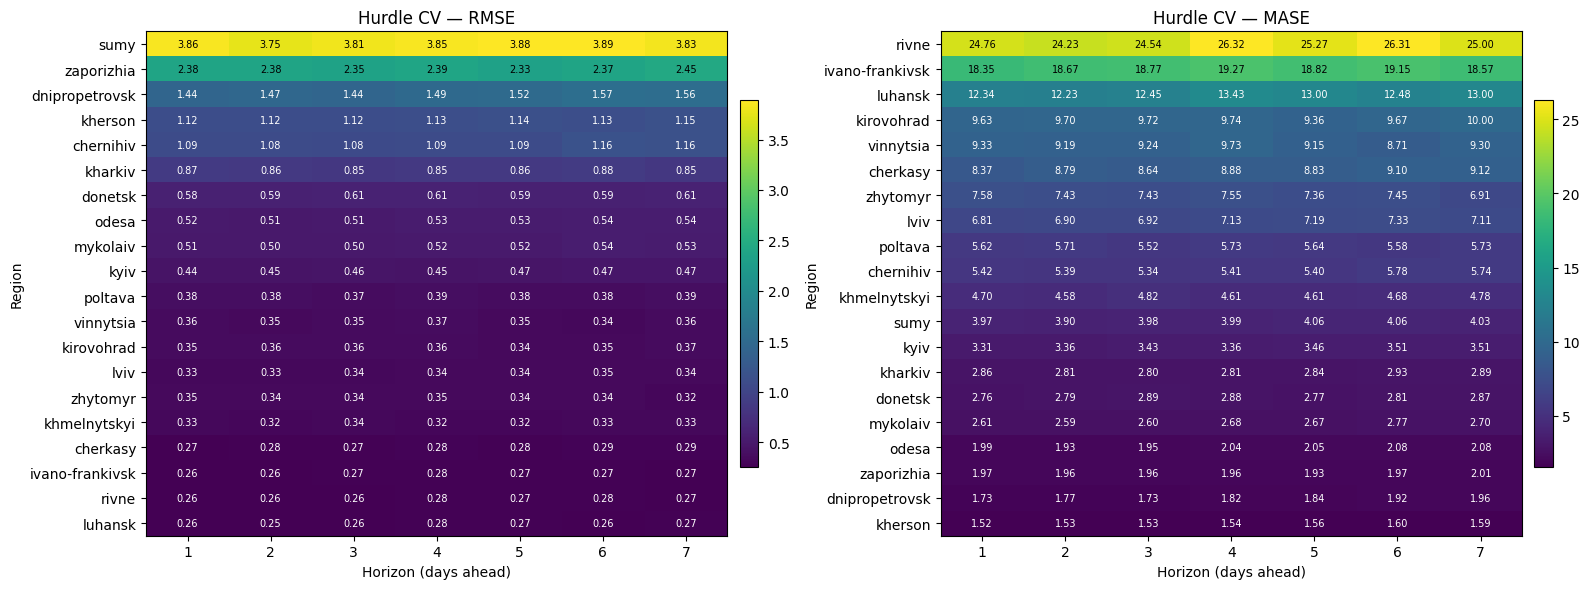


=== Classifier CV — Per-horizon ===
   horizon        F1   ROC_AUC    PR_AUC     Brier     n
0        1  0.660955  0.896351  0.714360  0.149752  1580
1        2  0.646562  0.899935  0.713251  0.147777  1580
2        3  0.640000  0.903302  0.730270  0.149511  1580
3        4  0.644628  0.902279  0.737025  0.151455  1580
4        5  0.645238  0.901029  0.741069  0.148282  1580
5        6  0.650235  0.905046  0.742241  0.147424  1580
6        7  0.656361  0.903219  0.749633  0.148847  1580


In [15]:
print("\n=== Hurdle CV — Per-region ===")
print(cv_results["per_region"][["region", "RMSE", "MAE", "MASE", "RMSSE", "n"]])

print("\n=== Hurdle CV — Per-horizon ===")
print(cv_results["per_horizon"][["horizon", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_region_horizon_heatmap(cv_results["per_region_horizon"], metric="RMSE",
                            title="Hurdle CV — RMSE", ax=axes[0])
plot_region_horizon_heatmap(cv_results["per_region_horizon"], metric="MASE",
                            title="Hurdle CV — MASE", ax=axes[1])
plt.tight_layout(); plt.show()

print("\n=== Classifier CV — Per-horizon ===")
print(cv_classif_results["per_horizon"][["horizon", "F1", "ROC_AUC", "PR_AUC", "Brier", "n"]])


## Classifier Calibration

In [16]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss

_CAL_EPS = 1e-6

def _logit(p):
    p = np.clip(p, _CAL_EPS, 1 - _CAL_EPS)
    return np.log(p / (1 - p))

def fit_sigmoid_cal(y_prob, y_true):
    lr = LogisticRegression(C=1e6, solver="lbfgs")
    lr.fit(_logit(y_prob).reshape(-1, 1), np.asarray(y_true, dtype=int))
    return lr

def apply_sigmoid_cal(lr, y_prob):
    return lr.predict_proba(_logit(y_prob).reshape(-1, 1))[:, 1]

def _oof_one_group(y, p, method, n_splits, random_state):
    """OOF calibrated probs for one contiguous subset."""
    minority = int(min(np.bincount(y))) if set(y) == {0, 1} else 0
    n_splits_eff = max(2, min(n_splits, minority)) if minority >= 2 else 0
    if n_splits_eff < 2:
        return apply_sigmoid_cal(fit_sigmoid_cal(p, y), p)
    out = np.zeros_like(p)
    skf = StratifiedKFold(n_splits=n_splits_eff, shuffle=True, random_state=random_state)
    for fit_idx, eval_idx in skf.split(p, y):
            c = fit_sigmoid_cal(p[fit_idx], y[fit_idx])
            out[eval_idx] = apply_sigmoid_cal(c, p[eval_idx])
    return out


def oof_calibrated_probs(long_df, method, n_splits=5, random_state=RANDOM_STATE, group_col=None):
    """Returns (y_true, p_raw, p_calibrated) arrays aligned to long_df rows."""
    y = long_df["y_true"].to_numpy().astype(int)
    p = long_df["y_prob"].to_numpy().astype(float)
    if group_col is None:
        return y, p, _oof_one_group(y, p, method, n_splits, random_state)
    p_cal  = np.zeros_like(p)
    groups = long_df[group_col].to_numpy()
    for g in pd.unique(groups):
        mask = (groups == g)
        p_cal[mask] = _oof_one_group(y[mask], p[mask], method, n_splits, random_state)
    return y, p, p_cal


def fit_final_calibrators_per_horizon(long_df, method):
    """Fit one calibrator per horizon on all CV rows. Returns {horizon: calibrator}."""
    out = {}
    for h, sub in long_df.groupby("horizon"):
        y_h = sub["y_true"].to_numpy().astype(int)
        p_h = sub["y_prob"].to_numpy().astype(float)
        if len(np.unique(y_h)) < 2:
            out[int(h)] = None
            continue
        out[int(h)] = fit_sigmoid_cal(p_h, y_h)
    return out


def apply_calibrator_per_horizon(long_df, calibrators_per_h, method):
    """Apply per-horizon calibrator to y_prob column. Returns calibrated prob array."""
    p_raw = long_df["y_prob"].to_numpy().astype(float)
    out   = p_raw.copy()
    for h, sub in long_df.groupby("horizon"):
        cal = calibrators_per_h.get(int(h))
        if cal is None:
            continue
        idx   = sub.index.to_numpy()
        sub_p = sub["y_prob"].to_numpy().astype(float)
        out[idx] =apply_sigmoid_cal(cal, sub_p)
    return out


In [17]:
# OOF calibration assessment — compare Brier before vs after each method
long_df_c_reset = long_df_c.reset_index(drop=True)

for method in ["sigmoid"]:
    y_true_cal, y_raw, y_cal = oof_calibrated_probs(long_df_c_reset, method=method, group_col="horizon")
    g_raw = _classif_metrics_hurdle(y_true_cal, y_raw)
    g_cal = _classif_metrics_hurdle(y_true_cal, y_cal)
    print(f"{method:10s}  Brier {g_raw['Brier']:.4f} -> {g_cal['Brier']:.4f} "
          f"| ROC-AUC {g_raw['ROC_AUC']:.4f} -> {g_cal['ROC_AUC']:.4f} "
          f"| PR-AUC {g_raw['PR_AUC']:.4f} -> {g_cal['PR_AUC']:.4f}")


sigmoid     Brier 0.1490 -> 0.0904 | ROC-AUC 0.9014 -> 0.9004 | PR-AUC 0.7297 -> 0.7291


In [18]:
# --- Change CAL_METHOD here and re-run this cell + the next to reevaluate ---
CAL_METHOD = "sigmoid"  

calibrators = fit_final_calibrators_per_horizon(long_df_c_reset, method=CAL_METHOD)
print(f"Fitted {sum(c is not None for c in calibrators.values())}/{len(calibrators)} "
      f"per-horizon calibrators  (method={CAL_METHOD!r})")

# Apply calibration to CV classifier predictions
long_df_c_cal          = long_df_c_reset.copy()
long_df_c_cal["y_prob"] = apply_calibrator_per_horizon(long_df_c_reset, calibrators, method=CAL_METHOD)

# Reconstruct hurdle predictions with calibrated probs
long_df_h_cal           = long_df_h.reset_index(drop=True).copy()
long_df_h_cal["y_pred"] = long_df_c_cal["y_prob"].values * long_df_r.reset_index(drop=True)["y_pred"].values

cv_results_cal = evaluate_hurdle_long(long_df_h_cal, mae_scales, rmse_scales)
g_unc = cv_results["global"]
g_cal = cv_results_cal["global"]
print(f"\nHurdle after {CAL_METHOD} calibration:")
print(f"  RMSE  : {g_unc['RMSE']:.4f}  ->  {g_cal['RMSE']:.4f}")
print(f"  MAE   : {g_unc['MAE']:.4f}  ->  {g_cal['MAE']:.4f}")
print(f"  MASE  : {g_unc['MASE_mean']:.4f}  ->  {g_cal['MASE_mean']:.4f}")
print(f"  RMSSE : {g_unc['RMSSE_mean']:.4f}  ->  {g_cal['RMSSE_mean']:.4f}")
print(f"  R²    : {g_unc['R2']:.4f}  ->  {g_cal['R2']:.4f}")

print("\n=== Calibrated hurdle — Per-region ===")
print(cv_results_cal["per_region"][["region", "RMSE", "MAE", "MASE", "RMSSE", "n"]])

print("\n=== Calibrated Hurdle — Per-horizon ===")
print(cv_results_cal["per_horizon"][["horizon", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

cv_classif_results_cal = evaluate_classif_long(long_df_c_cal)
print("\n=== Calibrated Classifier — Per-horizon ===")
print(cv_classif_results_cal["per_horizon"][["horizon", "F1", "ROC_AUC", "PR_AUC", "Brier", "n"]])


Fitted 7/7 per-horizon calibrators  (method='sigmoid')

Hurdle after sigmoid calibration:
  RMSE  : 1.1840  ->  1.1450
  MAE   : 0.6902  ->  0.4811
  MASE  : 6.8918  ->  1.6670
  RMSSE : 1.4759  ->  0.9406
  R²    : 0.3764  ->  0.4167

=== Calibrated hurdle — Per-region ===
             region      RMSE       MAE      MASE     RMSSE    n
0           luhansk  0.010599  0.009533  0.465511  0.064144  553
1      khmelnytskyi  0.111344  0.032318  0.473463  0.373780  553
2             odesa  0.246780  0.179852  0.697970  0.439210  553
3          cherkasy  0.112566  0.025500  0.830182  0.642275  553
4          mykolaiv  0.282786  0.199460  1.034369  0.546332  553
5              kyiv  0.275248  0.146446  1.100222  0.567197  553
6          zhytomyr  0.191889  0.051641  1.163900  0.796637  553
7              lviv  0.250090  0.049146  1.199991  1.009008  553
8           donetsk  0.354704  0.255656  1.238135  0.433131  553
9         vinnytsia  0.161906  0.049831  1.327323  0.768644  553
10       k

## Final Test Set Evaluation

In [19]:
def run_final_test(predict_stride=1, retrain_stride=OUTPUT_CHUNK_LEN):
    """Evaluate hurdle model on the held-out test set.

    Makes a 7-day prediction every predict_stride days (default: every day).
    Retrains both models every retrain_stride days (default: every 7 days).
    Training always starts from 80% of the full series.
    """
    full_target_c = [tr.append(vl).append(te)
                     for tr, vl, te in zip(train_target_c, val_target_c, test_target_c)]
    full_target_r = [tr.append(vl).append(te)
                     for tr, vl, te in zip(train_target_r, val_target_r, test_target_r)]
    full_weights_final = make_positive_only_weights(full_target_r)

    ref_ts         = full_target_c[0]
    n_total        = len(ref_ts)
    test_start_idx = int(TRAIN_VAL_END * n_total)
    n_regions      = len(full_target_c)

    fold_preds_c = [[] for _ in range(n_regions)]
    fold_preds_r = [[] for _ in range(n_regions)]
    fold_preds_h = [[] for _ in range(n_regions)]
    n_preds    = 0
    n_retrains = 0
    clf = None
    reg = None

    for t0 in range(test_start_idx, n_total - OUTPUT_CHUNK_LEN + 1, predict_stride):
        steps_since_start = t0 - test_start_idx

        # --- Retrain every retrain_stride steps ---
        if steps_since_start % retrain_stride == 0:
            retrain_time  = ref_ts.time_index[t0]
            train_c       = [ts.drop_after(retrain_time) for ts in full_target_c]
            train_r       = [ts.drop_after(retrain_time) for ts in full_target_r]
            train_weights = [w.drop_after(retrain_time)  for w  in full_weights_final]

            clf = get_event_classifier()
            clf.fit(series=train_c, past_covariates=full_past_covs_c,
                    future_covariates=full_fut_covs_c)

            reg = get_count_regressor()
            reg.fit(series=train_r, past_covariates=full_past_covs_r,
                    future_covariates=full_fut_covs_r, sample_weight=train_weights)

            n_retrains += 1
            print(f"   retrain {n_retrains}  (data up to {retrain_time.date()})")

        # --- Daily prediction: growing context, frozen model ---
        split_time    = ref_ts.time_index[t0]
        pred_series_c = [ts.drop_after(split_time) for ts in full_target_c]
        pred_series_r = [ts.drop_after(split_time) for ts in full_target_r]

        preds_c = clf.predict(
            n=OUTPUT_CHUNK_LEN, series=pred_series_c,
            past_covariates=full_past_covs_c, future_covariates=full_fut_covs_c,
            predict_likelihood_parameters=True, show_warnings=False,
        )
        preds_r = reg.predict(
            n=OUTPUT_CHUNK_LEN, series=pred_series_r,
            past_covariates=full_past_covs_r, future_covariates=full_fut_covs_r,
            show_warnings=False,
        )

        for r_idx, (pred_c, pred_r) in enumerate(zip(preds_c, preds_r)):
            prob_ts   = pred_c.univariate_component(pred_c.n_components - 1)
            hurdle_ts = TimeSeries.from_times_and_values(
                pred_r.time_index,
                (prob_ts.values().ravel() * pred_r.values().ravel()).reshape(-1, 1),
            )
            fold_preds_c[r_idx].append(prob_ts)
            fold_preds_r[r_idx].append(pred_r)
            fold_preds_h[r_idx].append(hurdle_ts)

        n_preds += 1

    print(f"   {n_preds} daily predictions, {n_retrains} retrains complete")
    return fold_preds_c, fold_preds_r, fold_preds_h, full_target_c, full_target_r


In [20]:
print("Running final test evaluation (retrain every 7 days) ...")
test_preds_c, test_preds_r, test_preds_h, full_target_c, full_target_r = run_final_test()


This model will treat target `series` lagged values as numeric input features (and not categorical).


Running final test evaluation (retrain every 7 days) ...
   retrain 1  (data up to 2024-08-05)


This model will treat target `series` lagged values as numeric input features (and not categorical).


   retrain 2  (data up to 2024-08-12)


This model will treat target `series` lagged values as numeric input features (and not categorical).


...

   retrain 22  (data up to 2024-12-30)


This model will treat target `series` lagged values as numeric input features (and not categorical).


   retrain 23  (data up to 2025-01-06)


This model will treat target `series` lagged values as numeric input features (and not categorical).


   retrain 24  (data up to 2025-01-13)
   164 daily predictions, 24 retrains complete


=== Final Test — Global metrics ===
  RMSE        : 2.0392
  MAE         : 0.9826
  MASE (mean) : 7.4956
  RMSSE (mean): 1.8670
  R²          : 0.3837
  n           : 22,960

=== Final Test — Per-region ===
             region      RMSE       MAE       MASE     RMSSE        R2     n
0           kherson  1.464885  1.169565   1.751736  1.154657 -0.186219  1148
1    dnipropetrovsk  2.066981  1.781504   2.367107  1.568682 -0.034305  1148
2             odesa  0.595828  0.568965   2.416299  1.113862 -0.981200  1148
3        zaporizhia  3.488810  3.089560   2.512842  1.397650  0.052847  1148
4          mykolaiv  0.684255  0.629198   3.324347  1.355444 -0.475988  1148
5           kharkiv  1.473348  1.101028   3.827926  2.199801 -0.042512  1148
6           donetsk  1.368258  0.814273   4.108099  1.752539 -0.050738  1148
7              sumy  7.155796  4.711426   4.396894  3.331876 -0.256508  1148
8              kyiv  0.872618  0.647688   5.053476  1.870722 -0.026299  1148
9           poltava  0.

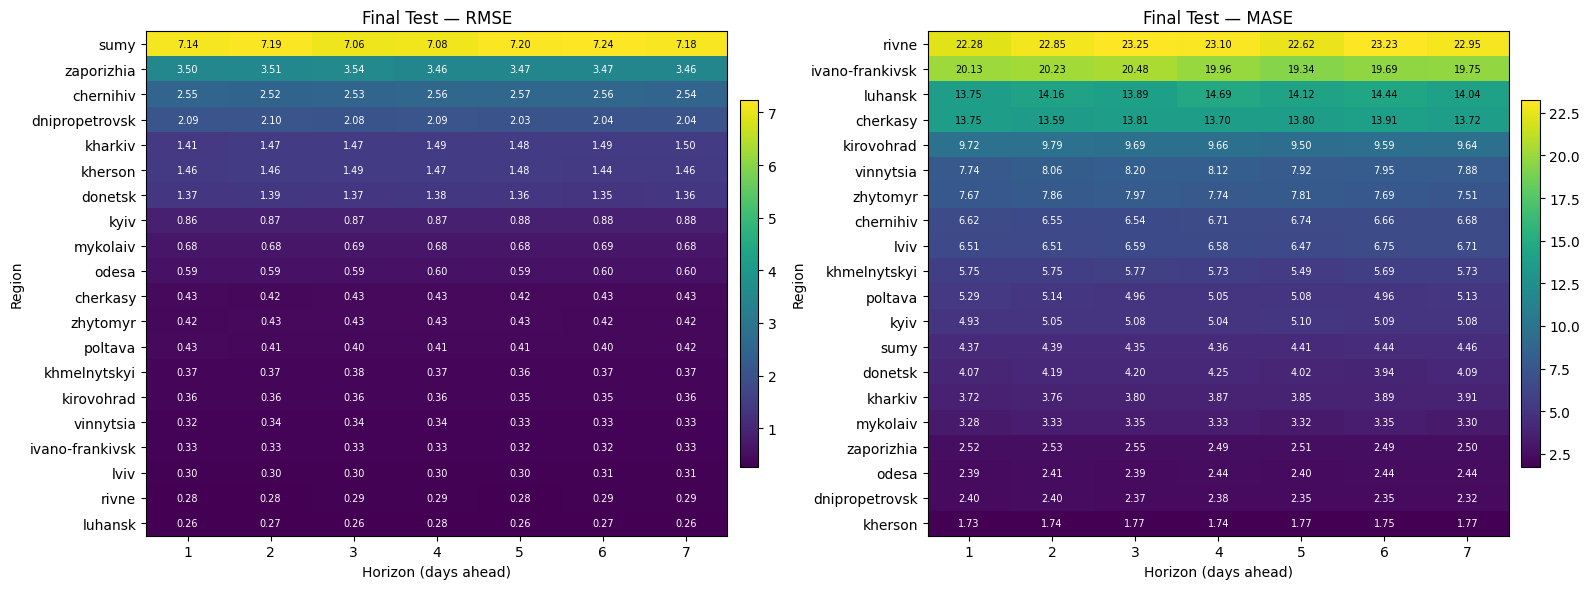


=== Final Test — Classifier standalone ===
   horizon        F1   ROC_AUC    PR_AUC     Brier     n
0        1  0.751825  0.905866  0.815697  0.147049  3280
1        2  0.746104  0.905863  0.817395  0.147118  3280
2        3  0.745098  0.904403  0.818771  0.145976  3280
3        4  0.743555  0.908530  0.822117  0.146716  3280
4        5  0.745170  0.904125  0.804109  0.146818  3280
5        6  0.748050  0.909118  0.819493  0.145144  3280
6        7  0.751934  0.908592  0.824474  0.143793  3280


In [21]:
test_long_c = (
    collect_predictions_long(full_target_c, test_preds_c, region_names)
    .rename(columns={"y_pred": "y_prob"})
)
test_long_r = collect_predictions_long(full_target_r, test_preds_r, region_names)
test_long_h = collect_predictions_long(full_target_r, test_preds_h, region_names)

# Naive scales from the 80% training data (no test leakage)
mae_scales_test, rmse_scales_test = compute_naive_scales(
    [tr.append(vl) for tr, vl in zip(train_target_r, val_target_r)],
    region_names, seasonality=7,
)

test_results = evaluate_hurdle_long(test_long_h, mae_scales_test, rmse_scales_test)
g = test_results["global"]
print("=== Final Test — Global metrics ===")
print(f"  RMSE        : {g['RMSE']:.4f}")
print(f"  MAE         : {g['MAE']:.4f}")
print(f"  MASE (mean) : {g['MASE_mean']:.4f}")
print(f"  RMSSE (mean): {g['RMSSE_mean']:.4f}")
print(f"  R²          : {g['R2']:.4f}")
print(f"  n           : {g['n']:,}")

print("\n=== Final Test — Per-region ===")
print(test_results["per_region"][["region", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

print("\n=== Final Test — Per-horizon ===")
print(test_results["per_horizon"][["horizon", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_region_horizon_heatmap(test_results["per_region_horizon"], metric="RMSE",
                            title="Final Test — RMSE", ax=axes[0])
plot_region_horizon_heatmap(test_results["per_region_horizon"], metric="MASE",
                            title="Final Test — MASE", ax=axes[1])
plt.tight_layout(); plt.show()

print("\n=== Final Test — Classifier standalone ===")
test_classif_results = evaluate_classif_long(test_long_c)
print(test_classif_results["per_horizon"][["horizon", "F1", "ROC_AUC", "PR_AUC", "Brier", "n"]])


=== Final Test after sigmoid calibration — Global metrics ===
  RMSE  : 2.0392  ->  2.0015
  MAE   : 0.9826  ->  0.7948
  MASE  : 7.4956  ->  2.5795
  RMSSE : 1.8670  ->  1.4794
  R²    : 0.3837  ->  0.4062

=== Calibrated Final Test — Per-region ===
             region      RMSE       MAE      MASE     RMSSE        R2     n
0              lviv  0.133474  0.032732  0.732099  0.509774  0.007953  1148
1           poltava  0.246652  0.088867  1.169217  0.894666 -0.024517  1148
2             odesa  0.432860  0.282162  1.198294  0.809203 -0.045636  1148
3      khmelnytskyi  0.223297  0.075529  1.206669  0.787131 -0.022749  1148
4         vinnytsia  0.173406  0.053212  1.322410  0.806760 -0.017298  1148
5           luhansk  0.134524  0.026260  1.468348  0.871168 -0.007724  1148
6        kirovohrad  0.189143  0.062646  1.751486  0.925917 -0.014984  1148
7           kherson  1.490296  1.177999  1.764369  1.174686 -0.227730  1148
8          zhytomyr  0.319222  0.095863  2.010128  1.307447 -0.02

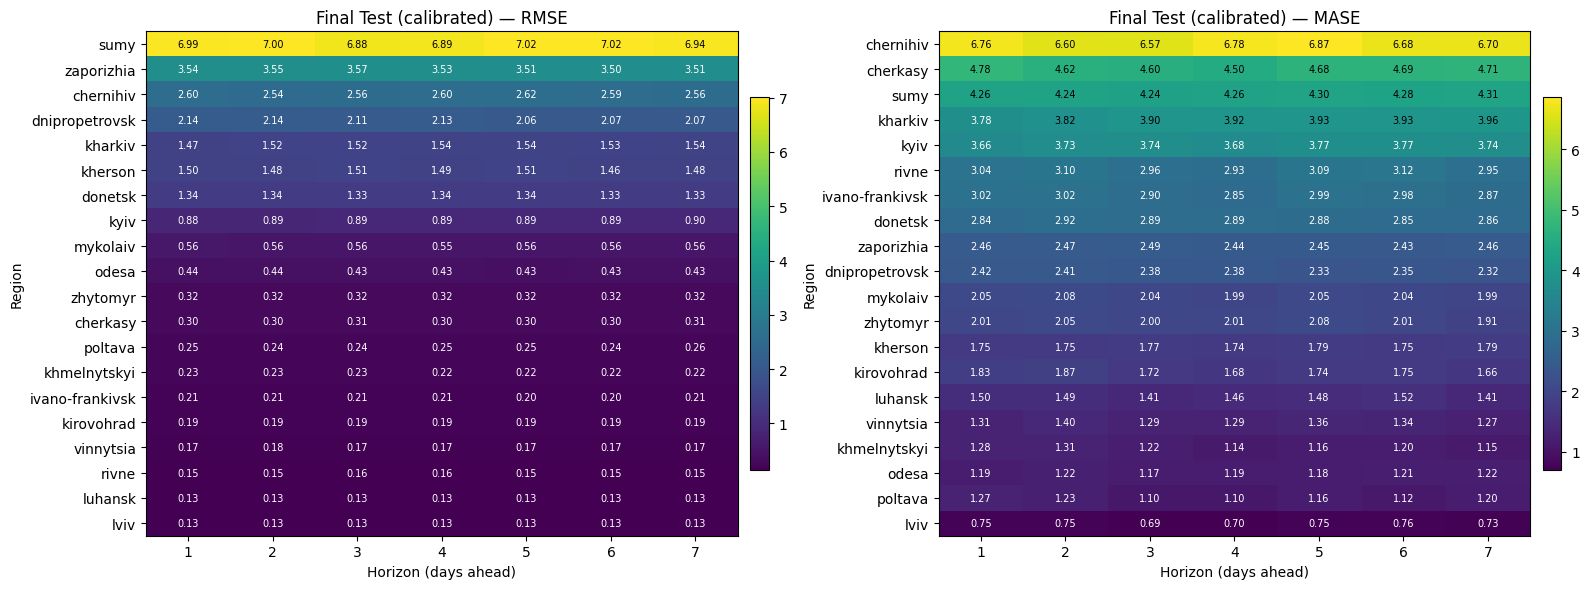


=== Calibrated Final Test — Classifier ===
   horizon        F1   ROC_AUC    PR_AUC     Brier     n
0        1  0.763057  0.905866  0.815697  0.106788  3280
1        2  0.766885  0.905863  0.817395  0.105878  3280
2        3  0.767391  0.904403  0.818771  0.106108  3280
3        4  0.769061  0.908530  0.822117  0.105472  3280
4        5  0.770732  0.904125  0.804109  0.106689  3280
5        6  0.777180  0.909118  0.819493  0.103650  3280
6        7  0.769231  0.908592  0.824474  0.104792  3280


In [22]:
# Apply the CV-fitted calibrators to the test predictions (no leakage: calibrators
# were fitted on validation-fold data, applied here to the held-out test set).
test_long_c_reset = test_long_c.reset_index(drop=True)
test_long_c_cal   = test_long_c_reset.copy()
test_long_c_cal["y_prob"] = apply_calibrator_per_horizon(
    test_long_c_reset, calibrators, method=CAL_METHOD
)

test_long_h_cal           = test_long_h.reset_index(drop=True).copy()
test_long_h_cal["y_pred"] = (
    test_long_c_cal["y_prob"].values
    * test_long_r.reset_index(drop=True)["y_pred"].values
)

test_results_cal = evaluate_hurdle_long(test_long_h_cal, mae_scales_test, rmse_scales_test)
g_unc = test_results["global"]
g_cal = test_results_cal["global"]

print(f"=== Final Test after {CAL_METHOD} calibration — Global metrics ===")
print(f"  RMSE  : {g_unc['RMSE']:.4f}  ->  {g_cal['RMSE']:.4f}")
print(f"  MAE   : {g_unc['MAE']:.4f}  ->  {g_cal['MAE']:.4f}")
print(f"  MASE  : {g_unc['MASE_mean']:.4f}  ->  {g_cal['MASE_mean']:.4f}")
print(f"  RMSSE : {g_unc['RMSSE_mean']:.4f}  ->  {g_cal['RMSSE_mean']:.4f}")
print(f"  R²    : {g_unc['R2']:.4f}  ->  {g_cal['R2']:.4f}")

print("\n=== Calibrated Final Test — Per-region ===")
print(test_results_cal["per_region"][["region", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

print("\n=== Calibrated Final Test — Per-horizon ===")
print(test_results_cal["per_horizon"][["horizon", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_region_horizon_heatmap(test_results_cal["per_region_horizon"], metric="RMSE",
                            title="Final Test (calibrated) — RMSE", ax=axes[0])
plot_region_horizon_heatmap(test_results_cal["per_region_horizon"], metric="MASE",
                            title="Final Test (calibrated) — MASE", ax=axes[1])
plt.tight_layout(); plt.show()

print("\n=== Calibrated Final Test — Classifier ===")
test_classif_results_cal = evaluate_classif_long(test_long_c_cal)
print(test_classif_results_cal["per_horizon"][["horizon", "F1", "ROC_AUC", "PR_AUC", "Brier", "n"]])


## Per-activity-level and per-region model comparison

The global hurdle model is re-run in two additional training paradigms:

- **Activity-level model**: one hurdle model per conflict-intensity group (low / medium / high), trained only on the homogeneous subset of regions it owns.
- **Local model**: one hurdle model per region (20 independent models), each trained exclusively on its own series and covariates.

Both use `predict_stride=1` / `retrain_stride=OUTPUT_CHUNK_LEN` (same decoupled stride as above).

In [ ]:
from collections import defaultdict
import time

print('current time', time.time())

def run_hurdle_cv_per_activity(predict_stride=1, retrain_stride=OUTPUT_CHUNK_LEN):
    """Expanding-window CV — one hurdle model per activity-level group."""
    groups = defaultdict(list)
    for i, region in enumerate(region_names):
        groups[regions_activity[region]].append(i)

    n_regions = len(target_for_cv_c)
    all_fp_c = [None] * n_regions
    all_fp_r = [None] * n_regions
    all_fp_h = [None] * n_regions

    for level in sorted(groups):
        indices = groups[level]
        print(f"\n--- Activity level {level} ({len(indices)} regions) ---")
        g_tc = [target_for_cv_c[i]  for i in indices]
        g_tr = [target_for_cv_r[i]  for i in indices]
        g_w  = [full_weights[i]     for i in indices]
        g_pc = [full_past_covs_c[i] for i in indices]
        g_fc = [full_fut_covs_c[i]  for i in indices]
        g_pr = [full_past_covs_r[i] for i in indices]
        g_fr = [full_fut_covs_r[i]  for i in indices]

        ref_ts    = g_tc[0]
        n_total   = len(ref_ts)
        start_idx = int(CV_START_VAL * n_total)
        fp_c = [[] for _ in indices]
        fp_r = [[] for _ in indices]
        fp_h = [[] for _ in indices]
        clf = reg = None
        n_preds = n_retrains = 0

        for t0 in range(start_idx, n_total - OUTPUT_CHUNK_LEN + 1, predict_stride):
            if (t0 - start_idx) % retrain_stride == 0:
                rt  = ref_ts.time_index[t0]
                clf = get_event_classifier()
                clf.fit(series=[ts.drop_after(rt) for ts in g_tc],
                        past_covariates=g_pc, future_covariates=g_fc)
                reg = get_count_regressor()
                reg.fit(series=[ts.drop_after(rt) for ts in g_tr],
                        past_covariates=g_pr, future_covariates=g_fr,
                        sample_weight=[w.drop_after(rt) for w in g_w])
                n_retrains += 1
                print(f"   retrain {n_retrains} (data up to {rt.date()})")

            st      = ref_ts.time_index[t0]
            preds_c = clf.predict(n=OUTPUT_CHUNK_LEN,
                                  series=[ts.drop_after(st) for ts in g_tc],
                                  past_covariates=g_pc, future_covariates=g_fc,
                                  predict_likelihood_parameters=True, show_warnings=False)
            preds_r = reg.predict(n=OUTPUT_CHUNK_LEN,
                                  series=[ts.drop_after(st) for ts in g_tr],
                                  past_covariates=g_pr, future_covariates=g_fr,
                                  show_warnings=False)
            for g_i, (pc, pr) in enumerate(zip(preds_c, preds_r)):
                prob   = pc.univariate_component(pc.n_components - 1)
                hurdle = TimeSeries.from_times_and_values(
                    pr.time_index,
                    (prob.values().ravel() * pr.values().ravel()).reshape(-1, 1),
                )
                fp_c[g_i].append(prob); fp_r[g_i].append(pr); fp_h[g_i].append(hurdle)
            n_preds += 1

        print(f"   {n_preds} predictions, {n_retrains} retrains complete")
        for g_i, orig_i in enumerate(indices):
            all_fp_c[orig_i] = fp_c[g_i]
            all_fp_r[orig_i] = fp_r[g_i]
            all_fp_h[orig_i] = fp_h[g_i]
    return all_fp_c, all_fp_r, all_fp_h


def run_hurdle_cv_per_region(predict_stride=1, retrain_stride=OUTPUT_CHUNK_LEN):
    """Expanding-window CV — one hurdle model per region (local)."""
    n_regions = len(target_for_cv_c)
    all_fp_c, all_fp_r, all_fp_h = [], [], []
    MIN_POSITIVE_SAMPLES = 50

    for i in range(n_regions):
        print(f"\n--- Region {i + 1}/{n_regions} ({region_names[i]}) ---")
        g_tc = [target_for_cv_c[i]];  g_tr = [target_for_cv_r[i]]; g_w = [full_weights[i]]
        g_pc = [full_past_covs_c[i]]; g_fc = [full_fut_covs_c[i]]
        g_pr = [full_past_covs_r[i]]; g_fr = [full_fut_covs_r[i]]

        ref_ts    = g_tc[0]
        n_total   = len(ref_ts)
        start_idx = int(CV_START_VAL * n_total)
        fp_c, fp_r, fp_h = [[]], [[]], [[]]
        clf = reg = None
        n_preds = n_retrains = 0
        use_dummy = False
        dummy_mean = 1.0

        for t0 in range(start_idx, n_total - OUTPUT_CHUNK_LEN + 1, predict_stride):
            if (t0 - start_idx) % retrain_stride == 0:
                rt  = ref_ts.time_index[t0]
                clf = get_event_classifier()
                clf.fit(series=[g_tc[0].drop_after(rt)], past_covariates=g_pc, future_covariates=g_fc)
                w_series = g_w[0].drop_after(rt)
                n_positive = (w_series.values() > 0).sum()
                if n_positive < MIN_POSITIVE_SAMPLES:
                    use_dummy = True
                    target_vals = g_tr[0].drop_after(rt).values()
                    pos_vals = target_vals[w_series.values() > 0]
                    dummy_mean = pos_vals.mean() if len(pos_vals) > 0 else 1.0
                    print(f"  [t0={t0}] Only {n_positive} samples. Using Dummy Regressor (mean={dummy_mean:.2f}).")
                else:
                    use_dummy = False
                    reg = get_count_regressor()
                    reg.fit(series=[g_tr[0].drop_after(rt)], past_covariates=g_pr, future_covariates=g_fr,
                            sample_weight=[w_series])
                n_retrains += 1

            st     = ref_ts.time_index[t0]
            pred_c = clf.predict(n=OUTPUT_CHUNK_LEN, series=[g_tc[0].drop_after(st)],
                                 past_covariates=g_pc, future_covariates=g_fc,
                                 predict_likelihood_parameters=True, show_warnings=False)[0]
            if use_dummy:
                pred_r = TimeSeries.from_times_and_values(
                    pred_c.time_index,
                    np.full((OUTPUT_CHUNK_LEN, 1), dummy_mean)
                )
            else:
                pred_r = reg.predict(n=OUTPUT_CHUNK_LEN, series=[g_tr[0].drop_after(st)],
                                     past_covariates=g_pr, future_covariates=g_fr,
                                     show_warnings=False)[0]
            prob   = pred_c.univariate_component(pred_c.n_components - 1)
            hurdle = TimeSeries.from_times_and_values(
                pred_r.time_index,
                (prob.values().ravel() * pred_r.values().ravel()).reshape(-1, 1),
            )
            fp_c[0].append(prob); fp_r[0].append(pred_r); fp_h[0].append(hurdle)
            n_preds += 1

        all_fp_c.append(fp_c[0]); all_fp_r.append(fp_r[0]); all_fp_h.append(fp_h[0])
    return all_fp_c, all_fp_r, all_fp_h

def run_final_test_per_activity(predict_stride=1, retrain_stride=OUTPUT_CHUNK_LEN):
    """Final test evaluation — one hurdle model per activity-level group."""
    full_tc = [tr.append(vl).append(te)
               for tr, vl, te in zip(train_target_c, val_target_c, test_target_c)]
    full_tr = [tr.append(vl).append(te)
               for tr, vl, te in zip(train_target_r, val_target_r, test_target_r)]
    fw = make_positive_only_weights(full_tr)

    groups = defaultdict(list)
    for i, region in enumerate(region_names):
        groups[regions_activity[region]].append(i)

    n_regions = len(full_tc)
    all_fp_c = [None] * n_regions
    all_fp_r = [None] * n_regions
    all_fp_h = [None] * n_regions

    for level in sorted(groups):
        indices = groups[level]
        print(f"\n--- Activity level {level} ({len(indices)} regions) ---")
        g_tc = [full_tc[i] for i in indices]; g_tr = [full_tr[i] for i in indices]
        g_w  = [fw[i]      for i in indices]
        g_pc = [full_past_covs_c[i] for i in indices]; g_fc = [full_fut_covs_c[i] for i in indices]
        g_pr = [full_past_covs_r[i] for i in indices]; g_fr = [full_fut_covs_r[i] for i in indices]

        ref_ts         = g_tc[0]
        n_total        = len(ref_ts)
        test_start_idx = int(TRAIN_VAL_END * n_total)
        fp_c = [[] for _ in indices]; fp_r = [[] for _ in indices]; fp_h = [[] for _ in indices]
        clf = reg = None
        n_preds = n_retrains = 0

        for t0 in range(test_start_idx, n_total - OUTPUT_CHUNK_LEN + 1, predict_stride):
            if (t0 - test_start_idx) % retrain_stride == 0:
                rt  = ref_ts.time_index[t0]
                clf = get_event_classifier()
                clf.fit(series=[ts.drop_after(rt) for ts in g_tc],
                        past_covariates=g_pc, future_covariates=g_fc)
                reg = get_count_regressor()
                reg.fit(series=[ts.drop_after(rt) for ts in g_tr],
                        past_covariates=g_pr, future_covariates=g_fr,
                        sample_weight=[w.drop_after(rt) for w in g_w])
                n_retrains += 1
                print(f"   retrain {n_retrains} (data up to {rt.date()})")

            st      = ref_ts.time_index[t0]
            preds_c = clf.predict(n=OUTPUT_CHUNK_LEN,
                                  series=[ts.drop_after(st) for ts in g_tc],
                                  past_covariates=g_pc, future_covariates=g_fc,
                                  predict_likelihood_parameters=True, show_warnings=False)
            preds_r = reg.predict(n=OUTPUT_CHUNK_LEN,
                                  series=[ts.drop_after(st) for ts in g_tr],
                                  past_covariates=g_pr, future_covariates=g_fr,
                                  show_warnings=False)
            for g_i, (pc, pr) in enumerate(zip(preds_c, preds_r)):
                prob   = pc.univariate_component(pc.n_components - 1)
                hurdle = TimeSeries.from_times_and_values(
                    pr.time_index,
                    (prob.values().ravel() * pr.values().ravel()).reshape(-1, 1),
                )
                fp_c[g_i].append(prob); fp_r[g_i].append(pr); fp_h[g_i].append(hurdle)
            n_preds += 1

        print(f"   {n_preds} predictions, {n_retrains} retrains complete")
        for g_i, orig_i in enumerate(indices):
            all_fp_c[orig_i] = fp_c[g_i]
            all_fp_r[orig_i] = fp_r[g_i]
            all_fp_h[orig_i] = fp_h[g_i]
    return all_fp_c, all_fp_r, all_fp_h, full_tc, full_tr


def run_final_test_per_region(predict_stride=1, retrain_stride=OUTPUT_CHUNK_LEN):
    """Final test evaluation — one hurdle model per region (local)."""
    full_tc = [tr.append(vl).append(te)
               for tr, vl, te in zip(train_target_c, val_target_c, test_target_c)]
    full_tr = [tr.append(vl).append(te)
               for tr, vl, te in zip(train_target_r, val_target_r, test_target_r)]
    fw = make_positive_only_weights(full_tr)

    all_fp_c, all_fp_r, all_fp_h = [], [], []
    n_regions = len(full_tc)
    
    # --- CONFIGURABLE DUMMY THRESHOLD ---
    MIN_POSITIVE_SAMPLES = 50

    for i in range(n_regions):
        print(f"\n--- Region {i + 1}/{n_regions} ({region_names[i]}) ---")
        g_tc = [full_tc[i]]; g_tr = [full_tr[i]]; g_w = [fw[i]]
        g_pc = [full_past_covs_c[i]]; g_fc = [full_fut_covs_c[i]]
        g_pr = [full_past_covs_r[i]]; g_fr = [full_fut_covs_r[i]]

        ref_ts         = g_tc[0]
        n_total        = len(ref_ts)
        test_start_idx = int(TRAIN_VAL_END * n_total)
        fp_c, fp_r, fp_h = [[]], [[]], [[]]
        clf = reg = None
        n_preds = n_retrains = 0
        
        # --- Dummy State Variables ---
        use_dummy = False
        dummy_mean = 1.0

        for t0 in range(test_start_idx, n_total - OUTPUT_CHUNK_LEN + 1, predict_stride):
            if (t0 - test_start_idx) % retrain_stride == 0:
                rt  = ref_ts.time_index[t0]
                clf = get_event_classifier()
                clf.fit(series=[g_tc[0].drop_after(rt)], past_covariates=g_pc, future_covariates=g_fc)
                
                # --- ADAPTIVE FALLBACK LOGIC ---
                w_series = g_w[0].drop_after(rt)
                n_positive = (w_series.values() > 0).sum()
                
                if n_positive < MIN_POSITIVE_SAMPLES:
                    use_dummy = True
                    target_vals = g_tr[0].drop_after(rt).values()
                    pos_vals = target_vals[w_series.values() > 0]
                    dummy_mean = pos_vals.mean() if len(pos_vals) > 0 else 1.0
                    print(f"  [t0={t0}] Only {n_positive} samples. Using Dummy Regressor (mean={dummy_mean:.2f}).")
                else:
                    use_dummy = False
                    reg = get_count_regressor()
                    reg.fit(series=[g_tr[0].drop_after(rt)], past_covariates=g_pr, future_covariates=g_fr,
                            sample_weight=[w_series])
                # -------------------------------
                
                n_retrains += 1

            st     = ref_ts.time_index[t0]
            pred_c = clf.predict(n=OUTPUT_CHUNK_LEN, series=[g_tc[0].drop_after(st)],
                                 past_covariates=g_pc, future_covariates=g_fc,
                                 predict_likelihood_parameters=True, show_warnings=False)[0]
            
            # --- DUMMY vs GBDT PREDICTION ---
            if use_dummy:
                pred_r = TimeSeries.from_times_and_values(
                    pred_c.time_index, 
                    np.full((OUTPUT_CHUNK_LEN, 1), dummy_mean)
                )
            else:
                pred_r = reg.predict(n=OUTPUT_CHUNK_LEN, series=[g_tr[0].drop_after(st)],
                                     past_covariates=g_pr, future_covariates=g_fr,
                                     show_warnings=False)[0]
            # --------------------------------

            prob   = pred_c.univariate_component(pred_c.n_components - 1)
            hurdle = TimeSeries.from_times_and_values(
                pred_r.time_index,
                (prob.values().ravel() * pred_r.values().ravel()).reshape(-1, 1),
            )
            fp_c[0].append(prob); fp_r[0].append(pred_r); fp_h[0].append(hurdle)
            n_preds += 1

        all_fp_c.append(fp_c[0]); all_fp_r.append(fp_r[0]); all_fp_h.append(fp_h[0])
    return all_fp_c, all_fp_r, all_fp_h, full_tc, full_tr

current time 1778611314.5708866


In [24]:
print("\nRunning local (per-region) final test ...")
loc_test_fp_c, loc_test_fp_r, loc_test_fp_h, loc_full_tc, loc_full_tr = run_final_test_per_region()

loc_test_long_h = collect_predictions_long(loc_full_tr, loc_test_fp_h, region_names)
loc_test_results = evaluate_hurdle_long(loc_test_long_h, mae_scales_test, rmse_scales_test)
g = loc_test_results["global"]
print(f"  MASE (mean): {g['MASE_mean']:.4f}  RMSSE (mean): {g['RMSSE_mean']:.4f}  R²: {g['R2']:.4f}")

print("Running activity-level final test ...")
act_test_fp_c, act_test_fp_r, act_test_fp_h, act_full_tc, act_full_tr = run_final_test_per_activity()

act_test_long_h = collect_predictions_long(act_full_tr, act_test_fp_h, region_names)
act_test_results = evaluate_hurdle_long(act_test_long_h, mae_scales_test, rmse_scales_test)
g = act_test_results["global"]
print(f"  MASE (mean): {g['MASE_mean']:.4f}  RMSSE (mean): {g['RMSSE_mean']:.4f}  R²: {g['R2']:.4f}")




This model will treat target `series` lagged values as numeric input features (and not categorical).



Running local (per-region) final test ...

--- Region 1/20 (cherkasy) ---
  [t0=677] Only 10 samples. Using Dummy Regressor (mean=1.00).


This model will treat target `series` lagged values as numeric input features (and not categorical).


  [t0=684] Only 10 samples. Using Dummy Regressor (mean=1.00).


This model will treat target `series` lagged values as numeric input features (and not categorical).


...

   retrain 22 (data up to 2024-12-30)


This model will treat target `series` lagged values as numeric input features (and not categorical).


   retrain 23 (data up to 2025-01-06)


This model will treat target `series` lagged values as numeric input features (and not categorical).


   retrain 24 (data up to 2025-01-13)
   164 predictions, 24 retrains complete
  MASE (mean): 12.5752  RMSSE (mean): 2.5843  R²: 0.3411


In [25]:
import pandas as pd

def _g(results, paradigm):
    return {"paradigm": paradigm, **results["global"]}

# cv_leaderboard = pd.DataFrame([
#     _g(cv_results,     "global"),
#     _g(act_cv_results, "activity"),
#     _g(loc_cv_results, "local"),
# ]).sort_values("MASE_mean").reset_index(drop=True)
# print("=== CV leaderboard (global vs activity-level vs local) ===")
# print(cv_leaderboard[["paradigm", "RMSE", "MAE", "MASE_mean", "RMSSE_mean", "R2", "n"]])

test_leaderboard_paradigms = pd.DataFrame([
    _g(test_results,     "global"),
    _g(act_test_results, "activity"),
    _g(loc_test_results, "local"),
]).sort_values("MASE_mean").reset_index(drop=True)
print("\n=== Test leaderboard (global vs activity-level vs local) ===")
print(test_leaderboard_paradigms[["paradigm", "RMSE", "MAE", "MASE_mean", "RMSSE_mean", "R2", "n"]])



=== Test leaderboard (global vs activity-level vs local) ===
   paradigm      RMSE       MAE  MASE_mean  RMSSE_mean        R2      n
0    global  2.039151  0.982586   7.495570    1.866990  0.383650  22960
1     local  2.166934  1.092777  11.138098    2.371744  0.303984  22960
2  activity  2.108295  1.139681  12.575170    2.584271  0.341143  22960


In [26]:
import pandas as pd
from IPython.display import display
from pathlib import Path

# Create a directory to store the combined hurdle metrics
RESULTS_DIR = Path("results/finalhurdle")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Gather Overall / Global Metrics
overall_rows = [
    {"paradigm": "global",   **test_results["global"]},
    {"paradigm": "activity", **act_test_results["global"]},
    {"paradigm": "local",    **loc_test_results["global"]},
]

# (Optional) Uncomment to include the calibrated global test results
# if "test_results_cal" in locals():
#     overall_rows.append({"paradigm": "global_calibrated", **test_results_cal["global"]})

df_overall = pd.DataFrame(overall_rows)
# Sort by a robust scale-free metric to show the best paradigm on top
df_overall = df_overall.sort_values("MASE_mean").reset_index(drop=True)


# Gather Per-Horizon Metrics
df_horizon = pd.concat([
    test_results["per_horizon"].assign(paradigm="global"),
    act_test_results["per_horizon"].assign(paradigm="activity"),
    loc_test_results["per_horizon"].assign(paradigm="local"),
], ignore_index=True)

# Sort to easily compare horizons across paradigms side-by-side
df_horizon = df_horizon.sort_values(["horizon", "paradigm"]).reset_index(drop=True)


# Gather Per-Region Metrics
df_region = pd.concat([
    test_results["per_region"].assign(paradigm="global"),
    act_test_results["per_region"].assign(paradigm="activity"),
    loc_test_results["per_region"].assign(paradigm="local"),
], ignore_index=True)

# Sort to easily compare regions across paradigms side-by-side
df_region = df_region.sort_values(["region", "paradigm"]).reset_index(drop=True)


# Save everything to CSV
df_overall.to_csv(RESULTS_DIR / "overall_metrics.csv", index=False)
df_horizon.to_csv(RESULTS_DIR / "per_horizon_metrics.csv", index=False)
df_region.to_csv(RESULTS_DIR / "per_region_metrics.csv", index=False)

print(f"Metrics saved to {RESULTS_DIR.resolve()}\n")

# Display the tables in the notebook
print("=== Overall Forecasting Metrics ===")
display(df_overall[["paradigm", "RMSE", "MAE", "MASE_mean", "RMSSE_mean", "R2", "n"]])

print("\n=== Per Forecasting Horizon Metrics ===")
# Adjust columns based on the metrics you care about most
display(df_horizon[["horizon", "paradigm", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

print("\n=== Per Region Metrics ==")
display(df_region[["region", "paradigm", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

# === Individual model performance on the test set (per horizon and per region) ===

# Build long DataFrames for activity-level and local individual models
act_test_long_c = (
    collect_predictions_long(act_full_tc, act_test_fp_c, region_names)
    .rename(columns={"y_pred": "y_prob"})
)
act_test_long_r = collect_predictions_long(act_full_tr, act_test_fp_r, region_names)

loc_test_long_c = (
    collect_predictions_long(loc_full_tc, loc_test_fp_c, region_names)
    .rename(columns={"y_pred": "y_prob"})
)
loc_test_long_r = collect_predictions_long(loc_full_tr, loc_test_fp_r, region_names)

# Evaluate classifier for activity and local paradigms (global already in test_classif_results from cell 26)
test_classif_results_act = evaluate_classif_long(act_test_long_c)
test_classif_results_loc = evaluate_classif_long(loc_test_long_c)

# Evaluate count regressor standalone for all 3 paradigms
test_reg_results_glo = evaluate_hurdle_long(test_long_r, mae_scales_test, rmse_scales_test)
test_reg_results_act = evaluate_hurdle_long(act_test_long_r, mae_scales_test, rmse_scales_test)
test_reg_results_loc = evaluate_hurdle_long(loc_test_long_r, mae_scales_test, rmse_scales_test)

# --- Classifier comparison tables ---
df_classif_horizon = pd.concat([
    test_classif_results["per_horizon"].assign(paradigm="global"),
    test_classif_results_act["per_horizon"].assign(paradigm="activity"),
    test_classif_results_loc["per_horizon"].assign(paradigm="local"),
], ignore_index=True).sort_values(["horizon", "paradigm"]).reset_index(drop=True)

df_classif_region = pd.concat([
    test_classif_results["per_region"].assign(paradigm="global"),
    test_classif_results_act["per_region"].assign(paradigm="activity"),
    test_classif_results_loc["per_region"].assign(paradigm="local"),
], ignore_index=True).sort_values(["region", "paradigm"]).reset_index(drop=True)

# --- Count regressor comparison tables ---
df_reg_horizon = pd.concat([
    test_reg_results_glo["per_horizon"].assign(paradigm="global"),
    test_reg_results_act["per_horizon"].assign(paradigm="activity"),
    test_reg_results_loc["per_horizon"].assign(paradigm="local"),
], ignore_index=True).sort_values(["horizon", "paradigm"]).reset_index(drop=True)

df_reg_region = pd.concat([
    test_reg_results_glo["per_region"].assign(paradigm="global"),
    test_reg_results_act["per_region"].assign(paradigm="activity"),
    test_reg_results_loc["per_region"].assign(paradigm="local"),
], ignore_index=True).sort_values(["region", "paradigm"]).reset_index(drop=True)

# Display
print("=== Classifier — Per Horizon ===")
display(df_classif_horizon[["horizon", "paradigm", "F1", "ROC_AUC", "PR_AUC", "Brier", "n"]])

print("\n=== Classifier — Per Region ===")
display(df_classif_region[["region", "paradigm", "F1", "ROC_AUC", "PR_AUC", "Brier", "n"]])

print("\n=== Count Regressor — Per Horizon ===")
display(df_reg_horizon[["horizon", "paradigm", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

print("\n=== Count Regressor — Per Region ===")
display(df_reg_region[["region", "paradigm", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

# Save
df_classif_horizon.to_csv(RESULTS_DIR / "classifier_per_horizon.csv", index=False)
df_classif_region.to_csv(RESULTS_DIR / "classifier_per_region.csv", index=False)
df_reg_horizon.to_csv(RESULTS_DIR / "regressor_per_horizon.csv", index=False)
df_reg_region.to_csv(RESULTS_DIR / "regressor_per_region.csv", index=False)
print(f"\nIndividual model metrics saved to {RESULTS_DIR.resolve()}")

Metrics saved to /home/newuser/thesis/results/finalhurdle

=== Overall Forecasting Metrics ===


,paradigm,RMSE,MAE,MASE_mean,RMSSE_mean,R2,n
0,global,2.039151,0.982586,7.495570,1.866990,0.383650,22960
1,local,2.166934,1.092777,11.138098,2.371744,0.303984,22960
2,activity,2.108295,1.139681,12.575170,2.584271,0.341143,22960



=== Per Forecasting Horizon Metrics ===


,horizon,paradigm,RMSE,MAE,MASE,RMSSE,R2,n
0,1,activity,2.095429,1.139876,12.733822,2.606323,0.327470,3280
1,1,global,2.035086,0.977849,7.431113,1.857136,0.365647,3280
2,1,local,2.140310,1.088159,11.155165,2.378849,0.298353,3280
3,2,activity,2.125832,1.144556,12.623498,2.599955,0.320740,3280
4,2,global,2.047841,0.983389,7.514608,1.868964,0.369666,3280
5,2,local,2.154654,1.082964,10.958657,2.357235,0.302196,3280
6,3,activity,2.098046,1.140283,12.498422,2.571854,0.339260,3280
7,3,global,2.028357,0.983705,7.550564,1.873649,0.382426,3280
8,3,local,2.149526,1.089549,11.031150,2.363976,0.306437,3280
9,4,activity,2.097766,1.135313,12.432872,2.559832,0.340517,3280



=== Per Region Metrics ==


...


=== Count Regressor — Per Horizon ===


,horizon,paradigm,RMSE,MAE,MASE,RMSSE,R2,n
0,1,activity,2.138111,1.435175,22.106157,3.959314,0.299794,3280
1,1,global,2.133733,1.461127,22.841375,4.081141,0.302659,3280
2,1,local,2.191229,1.436289,22.418867,3.976303,0.264571,3280
3,2,activity,2.169858,1.442451,21.851751,3.940034,0.292313,3280
4,2,global,2.158409,1.477760,23.137498,4.128350,0.299762,3280
5,2,local,2.217661,1.448738,22.452735,3.989592,0.260788,3280
6,3,activity,2.139788,1.437140,21.828999,3.929571,0.312707,3280
7,3,global,2.142479,1.487750,23.469939,4.182163,0.310977,3280
8,3,local,2.202983,1.450631,22.452903,3.986616,0.271511,3280
9,4,activity,2.127222,1.424535,21.649956,3.893816,0.321866,3280



=== Count Regressor — Per Region ===


,region,paradigm,RMSE,MAE,MASE,RMSSE,R2,n
0,cherkasy,activity,1.004673,0.954675,32.029356,5.819301,-10.374022,1148
1,cherkasy,global,1.111875,1.063888,35.693455,6.440241,-12.930819,1148
2,cherkasy,local,0.949509,0.901568,30.247605,5.499782,-9.159292,1148
3,chernihiv,activity,2.357847,1.780635,6.458411,3.327070,-0.012376,1148
4,chernihiv,global,2.330440,1.774393,6.435773,3.288397,0.011022,1148
5,chernihiv,local,2.462751,1.816783,6.589522,3.475096,-0.104465,1148
6,dnipropetrovsk,activity,1.978186,1.747314,2.321678,1.501293,0.052651,1148
7,dnipropetrovsk,global,1.996810,1.761093,2.339986,1.515427,0.034729,1148
8,dnipropetrovsk,local,1.978259,1.763605,2.343325,1.501348,0.052581,1148
9,donetsk,activity,1.641360,1.255627,6.334778,2.102343,-0.512050,1148



Individual model metrics saved to /home/newuser/thesis/results/finalhurdle


In [ ]:
# RUN HURDLE CV FOR RESULTS PLATT Calibration
print("Running activity-level hurdle CV ...")
act_cv_fp_c, act_cv_fp_r, act_cv_fp_h = run_hurdle_cv_per_activity()

act_cv_long_c = (
    collect_predictions_long(target_for_cv_c, act_cv_fp_c, region_names)
    .rename(columns={"y_pred": "y_prob"})
)
act_cv_long_r = collect_predictions_long(target_for_cv_r, act_cv_fp_r, region_names)
act_cv_long_h = collect_predictions_long(target_for_cv_r, act_cv_fp_h, region_names)

act_cv_results = evaluate_hurdle_long(act_cv_long_h, mae_scales, rmse_scales)
g = act_cv_results["global"]
print(f"  [Uncalibrated] MASE: {g['MASE_mean']:.4f}  RMSSE: {g['RMSSE_mean']:.4f}  R²: {g['R2']:.4f}")

# Refit Platt calibrators on activity-level CV predictions (per paradigm — not the global calibrators)
act_calibrators = fit_final_calibrators_per_horizon(act_cv_long_c.reset_index(drop=True), method="sigmoid")
print(f"  Fitted {sum(c is not None for c in act_calibrators.values())}/{len(act_calibrators)} activity calibrators")

# Apply calibration to CV predictions
act_cv_long_c_cal = act_cv_long_c.reset_index(drop=True).copy()
act_cv_long_c_cal["y_prob"] = apply_calibrator_per_horizon(
    act_cv_long_c.reset_index(drop=True), act_calibrators, method="sigmoid"
)
act_cv_long_h_cal = act_cv_long_h.reset_index(drop=True).copy()
act_cv_long_h_cal["y_pred"] = (
    act_cv_long_c_cal["y_prob"].values
    * act_cv_long_r.reset_index(drop=True)["y_pred"].values
)
act_cv_results_cal = evaluate_hurdle_long(act_cv_long_h_cal, mae_scales, rmse_scales)
g_cal = act_cv_results_cal["global"]
print(f"  [Calibrated CV] MASE: {g_cal['MASE_mean']:.4f}  RMSSE: {g_cal['RMSSE_mean']:.4f}  R²: {g_cal['R2']:.4f}")

# Apply same calibrators to already-computed test predictions (no leakage: calibrators fitted on CV only)
act_test_long_c_cal = act_test_long_c.reset_index(drop=True).copy()
act_test_long_c_cal["y_prob"] = apply_calibrator_per_horizon(
    act_test_long_c.reset_index(drop=True), act_calibrators, method="sigmoid"
)
act_test_long_h_cal = act_test_long_h.reset_index(drop=True).copy()
act_test_long_h_cal["y_pred"] = (
    act_test_long_c_cal["y_prob"].values
    * act_test_long_r.reset_index(drop=True)["y_pred"].values
)
act_test_results_cal = evaluate_hurdle_long(act_test_long_h_cal, mae_scales_test, rmse_scales_test)
g_test_cal = act_test_results_cal["global"]
print(f"  [Calibrated Test] MASE: {g_test_cal['MASE_mean']:.4f}  RMSSE: {g_test_cal['RMSSE_mean']:.4f}  R²: {g_test_cal['R2']:.4f}")



This model will treat target `series` lagged values as numeric input features (and not categorical).


Running activity-level hurdle CV ...

--- Activity level 1 (10 regions) ---
   retrain 1 (data up to 2024-05-11)


This model will treat target `series` lagged values as numeric input features (and not categorical).


   retrain 2 (data up to 2024-05-18)


This model will treat target `series` lagged values as numeric input features (and not categorical).


...

This model will treat target `series` lagged values as numeric input features (and not categorical).


   retrain 12 (data up to 2024-07-27)
   79 predictions, 12 retrains complete
  [Uncalibrated] MASE: 11.8493  RMSSE: 2.1372  R²: 0.3180
  Fitted 7/7 activity calibrators
  [Calibrated CV] MASE: 3.1124  RMSSE: 1.1166  R²: 0.3792


This model will treat target `series` lagged values as numeric input features (and not categorical).


  [Calibrated Test] MASE: 5.6564  RMSSE: 1.8094  R²: 0.3699

Running local (per-region) hurdle CV ...

--- Region 1/20 (cherkasy) ---


CatBoostError: catboost/private/libs/algo/tensor_search_helpers.cpp:565: Too few sampling units (subsample=0.8, bootstrap_type=MVS): please increase sampling rate or disable sampling

In [38]:
def run_hurdle_cv_per_region(predict_stride=1, retrain_stride=OUTPUT_CHUNK_LEN):
    """Expanding-window CV — one hurdle model per region (local)."""
    n_regions = len(target_for_cv_c)
    all_fp_c, all_fp_r, all_fp_h = [], [], []
    MIN_POSITIVE_SAMPLES = 50

    for i in range(n_regions):
        print(f"\n--- Region {i + 1}/{n_regions} ({region_names[i]}) ---")
        g_tc = [target_for_cv_c[i]];  g_tr = [target_for_cv_r[i]]; g_w = [full_weights[i]]
        g_pc = [full_past_covs_c[i]]; g_fc = [full_fut_covs_c[i]]
        g_pr = [full_past_covs_r[i]]; g_fr = [full_fut_covs_r[i]]

        ref_ts    = g_tc[0]
        n_total   = len(ref_ts)
        start_idx = int(CV_START_VAL * n_total)
        fp_c, fp_r, fp_h = [[]], [[]], [[]]
        clf = reg = None
        n_preds = n_retrains = 0
        use_dummy = False
        dummy_mean = 1.0

        for t0 in range(start_idx, n_total - OUTPUT_CHUNK_LEN + 1, predict_stride):
            if (t0 - start_idx) % retrain_stride == 0:
                rt  = ref_ts.time_index[t0]
                clf = get_event_classifier()
                clf.fit(series=[g_tc[0].drop_after(rt)], past_covariates=g_pc, future_covariates=g_fc)
                w_series = g_w[0].drop_after(rt)
                n_positive = (w_series.values() > 0).sum()
                if n_positive < MIN_POSITIVE_SAMPLES:
                    use_dummy = True
                    target_vals = g_tr[0].drop_after(rt).values()
                    pos_vals = target_vals[w_series.values() > 0]
                    dummy_mean = pos_vals.mean() if len(pos_vals) > 0 else 1.0
                    print(f"  [t0={t0}] Only {n_positive} samples. Using Dummy Regressor (mean={dummy_mean:.2f}).")
                else:
                    use_dummy = False
                    reg = get_count_regressor()
                    reg.fit(series=[g_tr[0].drop_after(rt)], past_covariates=g_pr, future_covariates=g_fr,
                            sample_weight=[w_series])
                n_retrains += 1

            st     = ref_ts.time_index[t0]
            pred_c = clf.predict(n=OUTPUT_CHUNK_LEN, series=[g_tc[0].drop_after(st)],
                                 past_covariates=g_pc, future_covariates=g_fc,
                                 predict_likelihood_parameters=True, show_warnings=False)[0]
            if use_dummy:
                pred_r = TimeSeries.from_times_and_values(
                    pred_c.time_index,
                    np.full((OUTPUT_CHUNK_LEN, 1), dummy_mean)
                )
            else:
                pred_r = reg.predict(n=OUTPUT_CHUNK_LEN, series=[g_tr[0].drop_after(st)],
                                     past_covariates=g_pr, future_covariates=g_fr,
                                     show_warnings=False)[0]
            prob   = pred_c.univariate_component(pred_c.n_components - 1)
            hurdle = TimeSeries.from_times_and_values(
                pred_r.time_index,
                (prob.values().ravel() * pred_r.values().ravel()).reshape(-1, 1),
            )
            fp_c[0].append(prob); fp_r[0].append(pred_r); fp_h[0].append(hurdle)
            n_preds += 1

        all_fp_c.append(fp_c[0]); all_fp_r.append(fp_r[0]); all_fp_h.append(fp_h[0])
    return all_fp_c, all_fp_r, all_fp_h


In [39]:
print("\nRunning local (per-region) hurdle CV ...")
loc_cv_fp_c, loc_cv_fp_r, loc_cv_fp_h = run_hurdle_cv_per_region()

loc_cv_long_c = (
    collect_predictions_long(target_for_cv_c, loc_cv_fp_c, region_names)
    .rename(columns={"y_pred": "y_prob"})
)
loc_cv_long_r = collect_predictions_long(target_for_cv_r, loc_cv_fp_r, region_names)
loc_cv_long_h = collect_predictions_long(target_for_cv_r, loc_cv_fp_h, region_names)

loc_cv_results = evaluate_hurdle_long(loc_cv_long_h, mae_scales, rmse_scales)
g = loc_cv_results["global"]
print(f"  [Uncalibrated] MASE: {g['MASE_mean']:.4f}  RMSSE: {g['RMSSE_mean']:.4f}  R²: {g['R2']:.4f}")

# Refit Platt calibrators on local CV predictions
loc_calibrators = fit_final_calibrators_per_horizon(loc_cv_long_c.reset_index(drop=True), method="sigmoid")
print(f"  Fitted {sum(c is not None for c in loc_calibrators.values())}/{len(loc_calibrators)} local calibrators")

# Apply calibration to CV predictions
loc_cv_long_c_cal = loc_cv_long_c.reset_index(drop=True).copy()
loc_cv_long_c_cal["y_prob"] = apply_calibrator_per_horizon(
    loc_cv_long_c.reset_index(drop=True), loc_calibrators, method="sigmoid"
)
loc_cv_long_h_cal = loc_cv_long_h.reset_index(drop=True).copy()
loc_cv_long_h_cal["y_pred"] = (
    loc_cv_long_c_cal["y_prob"].values
    * loc_cv_long_r.reset_index(drop=True)["y_pred"].values
)
loc_cv_results_cal = evaluate_hurdle_long(loc_cv_long_h_cal, mae_scales, rmse_scales)
g_cal = loc_cv_results_cal["global"]
print(f"  [Calibrated CV] MASE: {g_cal['MASE_mean']:.4f}  RMSSE: {g_cal['RMSSE_mean']:.4f}  R²: {g_cal['R2']:.4f}")

# Apply same calibrators to already-computed test predictions
loc_test_long_c_cal = loc_test_long_c.reset_index(drop=True).copy()
loc_test_long_c_cal["y_prob"] = apply_calibrator_per_horizon(
    loc_test_long_c.reset_index(drop=True), loc_calibrators, method="sigmoid"
)
loc_test_long_h_cal = loc_test_long_h.reset_index(drop=True).copy()
loc_test_long_h_cal["y_pred"] = (
    loc_test_long_c_cal["y_prob"].values
    * loc_test_long_r.reset_index(drop=True)["y_pred"].values
)
loc_test_results_cal = evaluate_hurdle_long(loc_test_long_h_cal, mae_scales_test, rmse_scales_test)
g_test_cal = loc_test_results_cal["global"]
print(f"  [Calibrated Test] MASE: {g_test_cal['MASE_mean']:.4f}  RMSSE: {g_test_cal['RMSSE_mean']:.4f}  R²: {g_test_cal['R2']:.4f}")

This model will treat target `series` lagged values as numeric input features (and not categorical).



Running local (per-region) hurdle CV ...

--- Region 1/20 (cherkasy) ---
  [t0=591] Only 9 samples. Using Dummy Regressor (mean=1.00).


This model will treat target `series` lagged values as numeric input features (and not categorical).


  [t0=598] Only 9 samples. Using Dummy Regressor (mean=1.00).


This model will treat target `series` lagged values as numeric input features (and not categorical).


...

  [t0=654] Only 12 samples. Using Dummy Regressor (mean=1.17).


This model will treat target `series` lagged values as numeric input features (and not categorical).


  [t0=661] Only 12 samples. Using Dummy Regressor (mean=1.17).


This model will treat target `series` lagged values as numeric input features (and not categorical).


  [t0=668] Only 14 samples. Using Dummy Regressor (mean=1.14).
  [Uncalibrated] MASE: 12.9770  RMSSE: 2.2023  R²: 0.2848
  Fitted 7/7 local calibrators
  [Calibrated CV] MASE: 5.1821  RMSSE: 1.2843  R²: 0.2766
  [Calibrated Test] MASE: 4.7035  RMSSE: 1.6961  R²: 0.2505


In [40]:
# ADD HERE THE COMPARISONS OF DIFFERENT TRAINING REGIMES (GLOBAL, PER ACTIVITY LEVEL, PER REGION)
# On the calibrated results (per-paradigm Platt / sigmoid calibration)

from IPython.display import display

# --- Global overview (CV) ---
print("=== CV Calibrated Hurdle — Global Comparison ===")
cv_cal_comparison = pd.DataFrame([
    {"paradigm": "global",   **cv_results_cal["global"]},
    {"paradigm": "activity", **act_cv_results_cal["global"]},
    {"paradigm": "local",    **loc_cv_results_cal["global"]},
]).sort_values("MASE_mean").reset_index(drop=True)
display(cv_cal_comparison[["paradigm", "RMSE", "MAE", "MASE_mean", "RMSSE_mean", "R2", "n"]])

# --- Per-horizon (CV) ---
print("\n=== CV Calibrated Hurdle — Per Horizon ===")
df_cv_cal_horizon = pd.concat([
    cv_results_cal["per_horizon"].assign(paradigm="global"),
    act_cv_results_cal["per_horizon"].assign(paradigm="activity"),
    loc_cv_results_cal["per_horizon"].assign(paradigm="local"),
], ignore_index=True).sort_values(["horizon", "paradigm"]).reset_index(drop=True)
display(df_cv_cal_horizon[["horizon", "paradigm", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

# --- Per-region (CV) ---
print("\n=== CV Calibrated Hurdle — Per Region ===")
df_cv_cal_region = pd.concat([
    cv_results_cal["per_region"].assign(paradigm="global"),
    act_cv_results_cal["per_region"].assign(paradigm="activity"),
    loc_cv_results_cal["per_region"].assign(paradigm="local"),
], ignore_index=True).sort_values(["region", "paradigm"]).reset_index(drop=True)
display(df_cv_cal_region[["region", "paradigm", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

# --- Global overview (Test) ---
print("\n=== Test Calibrated Hurdle — Global Comparison ===")
test_cal_comparison = pd.DataFrame([
    {"paradigm": "global",   **test_results_cal["global"]},
    {"paradigm": "activity", **act_test_results_cal["global"]},
    {"paradigm": "local",    **loc_test_results_cal["global"]},
]).sort_values("MASE_mean").reset_index(drop=True)
display(test_cal_comparison[["paradigm", "RMSE", "MAE", "MASE_mean", "RMSSE_mean", "R2", "n"]])

# --- Per-horizon (Test) ---
print("\n=== Test Calibrated Hurdle — Per Horizon ===")
df_test_cal_horizon = pd.concat([
    test_results_cal["per_horizon"].assign(paradigm="global"),
    act_test_results_cal["per_horizon"].assign(paradigm="activity"),
    loc_test_results_cal["per_horizon"].assign(paradigm="local"),
], ignore_index=True).sort_values(["horizon", "paradigm"]).reset_index(drop=True)
display(df_test_cal_horizon[["horizon", "paradigm", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

# --- Per-region (Test) ---
print("\n=== Test Calibrated Hurdle — Per Region ===")
df_test_cal_region = pd.concat([
    test_results_cal["per_region"].assign(paradigm="global"),
    act_test_results_cal["per_region"].assign(paradigm="activity"),
    loc_test_results_cal["per_region"].assign(paradigm="local"),
], ignore_index=True).sort_values(["region", "paradigm"]).reset_index(drop=True)
display(df_test_cal_region[["region", "paradigm", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

# Save
RESULTS_DIR_PATH = Path("results/finalhurdle")
cv_cal_comparison.to_csv(RESULTS_DIR_PATH / "cv_calibrated_overall.csv", index=False)
df_cv_cal_horizon.to_csv(RESULTS_DIR_PATH / "cv_calibrated_per_horizon.csv", index=False)
df_cv_cal_region.to_csv(RESULTS_DIR_PATH / "cv_calibrated_per_region.csv", index=False)
test_cal_comparison.to_csv(RESULTS_DIR_PATH / "test_calibrated_overall.csv", index=False)
df_test_cal_horizon.to_csv(RESULTS_DIR_PATH / "test_calibrated_per_horizon.csv", index=False)
df_test_cal_region.to_csv(RESULTS_DIR_PATH / "test_calibrated_per_region.csv", index=False)
print(f"\nCalibrated metrics saved to {RESULTS_DIR_PATH.resolve()}")

=== CV Calibrated Hurdle — Global Comparison ===


,paradigm,RMSE,MAE,MASE_mean,RMSSE_mean,R2,n
0,global,1.145008,0.481050,1.666970,0.940615,0.416715,11060
1,activity,1.181256,0.510580,3.112434,1.116607,0.379201,11060
2,local,1.275107,0.560088,5.182101,1.284346,0.276637,11060



=== CV Calibrated Hurdle — Per Horizon ===


,horizon,paradigm,RMSE,MAE,MASE,RMSSE,R2,n
0,1,activity,1.204293,0.518556,3.466497,1.159037,0.331856,1580
1,1,global,1.151200,0.476352,1.668988,0.939555,0.389469,1580
2,1,local,1.297023,0.561567,5.723957,1.321282,0.225001,1580
3,2,activity,1.138883,0.490237,2.831330,1.065713,0.401406,1580
4,2,global,1.131001,0.473848,1.653076,0.934530,0.409664,1580
5,2,local,1.249373,0.549696,5.120653,1.274462,0.279626,1580
6,3,activity,1.165357,0.501857,3.109632,1.116063,0.383237,1580
7,3,global,1.128624,0.473105,1.627305,0.932380,0.421505,1580
8,3,local,1.257301,0.551029,5.046348,1.263774,0.282074,1580
9,4,activity,1.185330,0.511898,3.167571,1.119780,0.369730,1580



=== CV Calibrated Hurdle — Per Region ===


...


=== Test Calibrated Hurdle — Per Horizon ===


,horizon,paradigm,RMSE,MAE,MASE,RMSSE,R2,n
0,1,activity,2.082504,0.935242,5.827293,1.839889,0.335742,3280
1,1,global,2.008995,0.795162,2.598308,1.479509,0.381809,3280
2,1,local,2.242372,0.922171,5.024819,1.729555,0.229840,3280
3,2,activity,2.048363,0.940105,6.317642,1.919413,0.369344,3280
4,2,global,2.008382,0.794803,2.604222,1.478362,0.393723,3280
5,2,local,2.229904,0.904963,4.726124,1.692129,0.252604,3280
6,3,activity,2.048182,0.924793,5.613147,1.803919,0.370294,3280
7,3,global,1.989482,0.793226,2.555097,1.479177,0.405871,3280
8,3,local,2.206243,0.903860,4.602969,1.695892,0.269354,3280
9,4,activity,2.053426,0.916514,5.500918,1.789045,0.368101,3280



=== Test Calibrated Hurdle — Per Region ===


,region,paradigm,RMSE,MAE,MASE,RMSSE,R2,n
0,cherkasy,activity,0.422105,0.362414,12.158975,2.444934,-1.007736,1148
1,cherkasy,global,0.305496,0.138702,4.653462,1.769505,-0.051662,1148
2,cherkasy,local,0.325932,0.244541,8.204357,1.887874,-0.197068,1148
3,chernihiv,activity,2.715510,1.927702,6.991828,3.831755,-0.342807,1148
4,chernihiv,global,2.583341,1.849705,6.708931,3.645256,-0.215274,1148
5,chernihiv,local,2.901523,2.077026,7.533431,4.094231,-0.533073,1148
6,dnipropetrovsk,activity,2.172293,1.785199,2.372016,1.648605,-0.142385,1148
7,dnipropetrovsk,global,2.101845,1.784491,2.371076,1.595141,-0.069491,1148
8,dnipropetrovsk,local,2.523875,2.015781,2.678394,1.915429,-0.542095,1148
9,donetsk,activity,1.347925,0.700466,3.533928,1.726495,-0.019741,1148



Calibrated metrics saved to /home/newuser/thesis/results/finalhurdle


In [50]:
# === Sigmoid-calibrated classifier performance across all paradigms ===
# Global results already computed above as test_classif_results_cal
act_test_classif_cal = evaluate_classif_long(act_test_long_c_cal)
loc_test_classif_cal = evaluate_classif_long(loc_test_long_c_cal)

# --- Per-horizon ---
print("=== Sigmoid-Calibrated Classifier — Per Horizon (Test) ===")
df_test_classif_cal_horizon = pd.concat([
    test_classif_results_cal["per_horizon"].assign(paradigm="global"),
    act_test_classif_cal["per_horizon"].assign(paradigm="activity"),
    loc_test_classif_cal["per_horizon"].assign(paradigm="local"),
], ignore_index=True).sort_values(["horizon", "paradigm"]).reset_index(drop=True)
display(df_test_classif_cal_horizon[["horizon", "paradigm", "F1", "ROC_AUC", "PR_AUC", "Brier", "n"]])

# --- Per-region ---
print("\n=== Sigmoid-Calibrated Classifier — Per Region (Test) ===")
df_test_classif_cal_region = pd.concat([
    test_classif_results_cal["per_region"].assign(paradigm="global"),
    act_test_classif_cal["per_region"].assign(paradigm="activity"),
    loc_test_classif_cal["per_region"].assign(paradigm="local"),
], ignore_index=True).sort_values(["region", "paradigm"]).reset_index(drop=True)
display(df_test_classif_cal_region[["region", "paradigm", "F1", "ROC_AUC", "PR_AUC", "Brier", "n"]])

# --- Save to CSV ---
df_test_classif_cal_horizon.to_csv(RESULTS_DIR_PATH / "sigmoid_cal_classifier_per_horizon.csv", index=False)
df_test_classif_cal_region.to_csv(RESULTS_DIR_PATH / "sigmoid_cal_classifier_per_region.csv", index=False)
print(f"\nSaved to {RESULTS_DIR_PATH.resolve()}")

=== Sigmoid-Calibrated Classifier — Per Horizon (Test) ===


,horizon,paradigm,F1,ROC_AUC,PR_AUC,Brier,n
0,1,activity,0.522952,0.780174,0.621649,0.164945,3280
1,1,global,0.763057,0.905866,0.815697,0.106788,3280
2,1,local,0.462454,0.838256,0.715290,0.146142,3280
3,2,activity,0.597647,0.799002,0.649847,0.170246,3280
4,2,global,0.766885,0.905863,0.817395,0.105878,3280
5,2,local,0.532770,0.845312,0.730226,0.140941,3280
6,3,activity,0.574573,0.800270,0.656034,0.158685,3280
7,3,global,0.767391,0.904403,0.818771,0.106108,3280
8,3,local,0.548939,0.838001,0.722785,0.141814,3280
9,4,activity,0.586458,0.813537,0.664045,0.153550,3280



=== Sigmoid-Calibrated Classifier — Per Region (Test) ===


,region,paradigm,F1,ROC_AUC,PR_AUC,Brier,n
0,cherkasy,activity,0.144737,0.540404,0.108041,0.167400,1148
1,cherkasy,global,0.000000,0.432235,0.095904,0.093491,1148
2,cherkasy,local,0.043796,0.540349,0.121964,0.106232,1148
3,chernihiv,activity,0.767236,0.596953,0.859425,0.225273,1148
4,chernihiv,global,0.888672,0.538048,0.833151,0.174926,1148
5,chernihiv,local,0.600806,0.542849,0.854196,0.292179,1148
6,dnipropetrovsk,activity,0.691034,0.647005,0.794232,0.229422,1148
7,dnipropetrovsk,global,0.820951,0.627076,0.778889,0.208024,1148
8,dnipropetrovsk,local,0.240664,0.537614,0.726280,0.338371,1148
9,donetsk,activity,0.259459,0.519316,0.245382,0.226062,1148



Saved to /home/newuser/thesis/results/finalhurdle


## Venn-Abers Calibration and Test Evaluation

Venn-Abers calibration is applied post-hoc as an alternative to Platt scaling. Per-paradigm calibrators are fitted on the respective CV classifier predictions (global CV → global calibrator, activity-level CV → activity calibrator, local CV → local calibrator) and then applied to the held-out test predictions — no model retraining is required.

This section also reports individual model performance (classifier and count regressor) per prediction horizon and per region for all three training paradigms.

In [44]:
!uv pip install venn-abers


Resolved 11 packages in 290ms                                        
   Building venn-abers==1.5.3                                          
   Building venn-abers==1.5.3                                  
   Building venn-abers==1.5.3                                  
   Building venn-abers==1.5.3                                  
   Building venn-abers==1.5.3                                  
   Building venn-abers==1.5.3                                  
      Built venn-abers==1.5.3                                  
Prepared 1 package in 1.08s                                              
Installed 1 package in 2ms                                  
 + venn-abers==1.5.3


In [45]:
from venn_abers import VennAbersCalibrator


def collect_va_cal_data_per_horizon(long_df):
    """Store {p_cal, y_cal} per horizon from CV predictions for manual Venn-Abers."""
    out = {}
    for h, sub in long_df.groupby("horizon"):
        y_h = sub["y_true"].to_numpy().astype(int)
        p_h = sub["y_prob"].to_numpy().astype(float)
        if len(np.unique(y_h)) < 2:
            out[int(h)] = None
            continue
        out[int(h)] = {
            "p_cal": np.column_stack([1.0 - p_h, p_h]),
            "y_cal": y_h,
        }
    return out


def apply_venn_abers_per_horizon(long_df, va_cal_data_per_h):
    """Apply per-horizon Venn-Abers calibration. Returns calibrated prob array."""
    p_raw = long_df["y_prob"].to_numpy().astype(float)
    out = p_raw.copy()
    va = VennAbersCalibrator()
    for h, sub in long_df.groupby("horizon"):
        cal_data = va_cal_data_per_h.get(int(h))
        if cal_data is None:
            continue
        idx = sub.index.to_numpy()
        p_test = np.column_stack([1.0 - sub["y_prob"].to_numpy(), sub["y_prob"].to_numpy()])
        p_prime = va.predict_proba(
            p_cal=cal_data["p_cal"],
            y_cal=cal_data["y_cal"],
            p_test=p_test.astype(float),
        )
        out[idx] = p_prime[:, 1]
    return out

In [46]:
# Collect Venn-Abers calibration data per paradigm from CV classifier predictions
# Each paradigm gets its own calibrator (fitted on its own CV data)
print("Collecting Venn-Abers calibration data per paradigm ...")
va_cal_global   = collect_va_cal_data_per_horizon(long_df_c.reset_index(drop=True))
va_cal_activity = collect_va_cal_data_per_horizon(act_cv_long_c.reset_index(drop=True))
va_cal_local    = collect_va_cal_data_per_horizon(loc_cv_long_c.reset_index(drop=True))

for name, cal in [("global", va_cal_global), ("activity", va_cal_activity), ("local", va_cal_local)]:
    n_fitted = sum(v is not None for v in cal.values())
    print(f"  {name}: {n_fitted}/{len(cal)} horizons have calibration data")

  global: 7/7 horizons have calibration data
  activity: 7/7 horizons have calibration data
  local: 7/7 horizons have calibration data


In [47]:
# Apply Venn-Abers calibration to test predictions — global paradigm
print("Applying Venn-Abers to global test predictions ...")
test_long_c_va = test_long_c.reset_index(drop=True).copy()
test_long_c_va["y_prob"] = apply_venn_abers_per_horizon(
    test_long_c.reset_index(drop=True), va_cal_global
)
test_long_h_va = test_long_h.reset_index(drop=True).copy()
test_long_h_va["y_pred"] = (
    test_long_c_va["y_prob"].values
    * test_long_r.reset_index(drop=True)["y_pred"].values
)
test_results_va_global = evaluate_hurdle_long(test_long_h_va, mae_scales_test, rmse_scales_test)
g = test_results_va_global["global"]
print(f"  [VA global] MASE: {g['MASE_mean']:.4f}  RMSSE: {g['RMSSE_mean']:.4f}  R²: {g['R2']:.4f}")

# Apply Venn-Abers calibration — activity paradigm
print("Applying Venn-Abers to activity-level test predictions ...")
act_test_long_c_va = act_test_long_c.reset_index(drop=True).copy()
act_test_long_c_va["y_prob"] = apply_venn_abers_per_horizon(
    act_test_long_c.reset_index(drop=True), va_cal_activity
)
act_test_long_h_va = act_test_long_h.reset_index(drop=True).copy()
act_test_long_h_va["y_pred"] = (
    act_test_long_c_va["y_prob"].values
    * act_test_long_r.reset_index(drop=True)["y_pred"].values
)
test_results_va_activity = evaluate_hurdle_long(act_test_long_h_va, mae_scales_test, rmse_scales_test)
g = test_results_va_activity["global"]
print(f"  [VA activity] MASE: {g['MASE_mean']:.4f}  RMSSE: {g['RMSSE_mean']:.4f}  R²: {g['R2']:.4f}")

# Apply Venn-Abers calibration — local paradigm
print("Applying Venn-Abers to local (per-region) test predictions ...")
loc_test_long_c_va = loc_test_long_c.reset_index(drop=True).copy()
loc_test_long_c_va["y_prob"] = apply_venn_abers_per_horizon(
    loc_test_long_c.reset_index(drop=True), va_cal_local
)
loc_test_long_h_va = loc_test_long_h.reset_index(drop=True).copy()
loc_test_long_h_va["y_pred"] = (
    loc_test_long_c_va["y_prob"].values
    * loc_test_long_r.reset_index(drop=True)["y_pred"].values
)
test_results_va_local = evaluate_hurdle_long(loc_test_long_h_va, mae_scales_test, rmse_scales_test)
g = test_results_va_local["global"]
print(f"  [VA local] MASE: {g['MASE_mean']:.4f}  RMSSE: {g['RMSSE_mean']:.4f}  R²: {g['R2']:.4f}")

Applying Venn-Abers to global test predictions ...
  [VA global] MASE: 2.8128  RMSSE: 1.4734  R²: 0.4263
Applying Venn-Abers to activity-level test predictions ...
  [VA activity] MASE: 5.6389  RMSSE: 1.8157  R²: 0.3735
Applying Venn-Abers to local (per-region) test predictions ...
  [VA local] MASE: 4.8040  RMSSE: 1.6893  R²: 0.2622


In [48]:
from IPython.display import display

# --- Global overview ---
print("=== Venn-Abers Calibrated Hurdle — Global Comparison ===")
va_comparison = pd.DataFrame([
    {"paradigm": "global",   **test_results_va_global["global"]},
    {"paradigm": "activity", **test_results_va_activity["global"]},
    {"paradigm": "local",    **test_results_va_local["global"]},
]).sort_values("MASE_mean").reset_index(drop=True)
display(va_comparison[["paradigm", "RMSE", "MAE", "MASE_mean", "RMSSE_mean", "R2", "n"]])

# --- Per horizon ---
print("\n=== Venn-Abers Calibrated Hurdle — Per Horizon ===")
df_va_horizon = pd.concat([
    test_results_va_global["per_horizon"].assign(paradigm="global"),
    test_results_va_activity["per_horizon"].assign(paradigm="activity"),
    test_results_va_local["per_horizon"].assign(paradigm="local"),
], ignore_index=True).sort_values(["horizon", "paradigm"]).reset_index(drop=True)
display(df_va_horizon[["horizon", "paradigm", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

# --- Per region ---
print("\n=== Venn-Abers Calibrated Hurdle — Per Region ===")
df_va_region = pd.concat([
    test_results_va_global["per_region"].assign(paradigm="global"),
    test_results_va_activity["per_region"].assign(paradigm="activity"),
    test_results_va_local["per_region"].assign(paradigm="local"),
], ignore_index=True).sort_values(["region", "paradigm"]).reset_index(drop=True)
display(df_va_region[["region", "paradigm", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

# Save
RESULTS_DIR_PATH = Path("results/finalhurdle")
va_comparison.to_csv(RESULTS_DIR_PATH / "va_overall.csv", index=False)
df_va_horizon.to_csv(RESULTS_DIR_PATH / "va_per_horizon.csv", index=False)
df_va_region.to_csv(RESULTS_DIR_PATH / "va_per_region.csv", index=False)
print(f"\nVenn-Abers hurdle metrics saved to {RESULTS_DIR_PATH.resolve()}")

=== Venn-Abers Calibrated Hurdle — Global Comparison ===


,paradigm,RMSE,MAE,MASE_mean,RMSSE_mean,R2,n
0,global,1.967383,0.786650,2.812804,1.473373,0.426272,22960
1,local,2.231009,0.909098,4.803984,1.689319,0.262213,22960
2,activity,2.055837,0.921322,5.638856,1.815708,0.373522,22960



=== Venn-Abers Calibrated Hurdle — Per Horizon ===


,horizon,paradigm,RMSE,MAE,MASE,RMSSE,R2,n
0,1,activity,2.065051,0.930243,5.821765,1.852314,0.346829,3280
1,1,global,1.981509,0.790305,2.792194,1.474409,0.398608,3280
2,1,local,2.224949,0.921723,5.119389,1.724862,0.241762,3280
3,2,activity,2.060493,0.947541,6.453625,1.944758,0.361853,3280
4,2,global,1.988092,0.786825,2.855947,1.474420,0.405911,3280
5,2,local,2.207892,0.899315,4.823643,1.679968,0.267287,3280
6,3,activity,2.042146,0.920985,5.578957,1.811281,0.374000,3280
7,3,global,1.956014,0.783001,2.787770,1.472626,0.425693,3280
8,3,local,2.169964,0.892737,4.785414,1.688139,0.293185,3280
9,4,activity,2.052153,0.916288,5.471727,1.798906,0.368884,3280



=== Venn-Abers Calibrated Hurdle — Per Region ===


,region,paradigm,RMSE,MAE,MASE,RMSSE,R2,n
0,cherkasy,activity,0.430491,0.361981,12.144463,2.493507,-1.088304,1148
1,cherkasy,global,0.302724,0.152972,5.132197,1.753448,-0.032662,1148
2,cherkasy,local,0.329046,0.240193,8.058489,1.905913,-0.220053,1148
3,chernihiv,activity,2.704994,1.926896,6.988904,3.816916,-0.332427,1148
4,chernihiv,global,2.547177,1.836631,6.661509,3.594227,-0.181487,1148
5,chernihiv,local,2.866478,2.061674,7.477747,4.044780,-0.496263,1148
6,dnipropetrovsk,activity,2.158569,1.774431,2.357709,1.638190,-0.127996,1148
7,dnipropetrovsk,global,2.070611,1.759562,2.337953,1.571436,-0.037941,1148
8,dnipropetrovsk,local,2.513675,2.011242,2.672363,1.907689,-0.529657,1148
9,donetsk,activity,1.353651,0.706052,3.562114,1.733830,-0.028423,1148



Venn-Abers hurdle metrics saved to /home/newuser/thesis/results/finalhurdle


In [49]:
# === Venn-Abers calibrated classifier performance ===
test_classif_va_global   = evaluate_classif_long(test_long_c_va)
test_classif_va_activity = evaluate_classif_long(act_test_long_c_va)
test_classif_va_local    = evaluate_classif_long(loc_test_long_c_va)

# Classifier per horizon
print("=== VA Classifier — Per Horizon ===")
df_classif_va_horizon = pd.concat([
    test_classif_va_global["per_horizon"].assign(paradigm="global"),
    test_classif_va_activity["per_horizon"].assign(paradigm="activity"),
    test_classif_va_local["per_horizon"].assign(paradigm="local"),
], ignore_index=True).sort_values(["horizon", "paradigm"]).reset_index(drop=True)
display(df_classif_va_horizon[["horizon", "paradigm", "F1", "ROC_AUC", "PR_AUC", "Brier", "n"]])

# Classifier per region
print("\n=== VA Classifier — Per Region ===")
df_classif_va_region = pd.concat([
    test_classif_va_global["per_region"].assign(paradigm="global"),
    test_classif_va_activity["per_region"].assign(paradigm="activity"),
    test_classif_va_local["per_region"].assign(paradigm="local"),
], ignore_index=True).sort_values(["region", "paradigm"]).reset_index(drop=True)
display(df_classif_va_region[["region", "paradigm", "F1", "ROC_AUC", "PR_AUC", "Brier", "n"]])

# Count regressor performance is not affected by calibration — reuse from cell 32
print("\n=== Count Regressor — Per Horizon (reference, same as uncalibrated) ===")
display(df_reg_horizon[["horizon", "paradigm", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

print("\n=== Count Regressor — Per Region (reference, same as uncalibrated) ===")
display(df_reg_region[["region", "paradigm", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

# Save
RESULTS_DIR_PATH = Path("results/finalhurdle")
df_classif_va_horizon.to_csv(RESULTS_DIR_PATH / "va_classifier_per_horizon.csv", index=False)
df_classif_va_region.to_csv(RESULTS_DIR_PATH / "va_classifier_per_region.csv", index=False)
print(f"\nVA classifier metrics saved to {RESULTS_DIR_PATH.resolve()}")

=== VA Classifier — Per Horizon ===


,horizon,paradigm,F1,ROC_AUC,PR_AUC,Brier,n
0,1,activity,0.542373,0.779326,0.601801,0.169942,3280
1,1,global,0.767356,0.904670,0.800237,0.106904,3280
2,1,local,0.522968,0.838156,0.695548,0.149729,3280
3,2,activity,0.610573,0.798258,0.633695,0.173924,3280
4,2,global,0.752520,0.903212,0.800222,0.106992,3280
5,2,local,0.561475,0.846165,0.708380,0.139658,3280
6,3,activity,0.597678,0.799132,0.640594,0.161376,3280
7,3,global,0.718367,0.904124,0.808850,0.107165,3280
8,3,local,0.592303,0.838119,0.699543,0.139353,3280
9,4,activity,0.599366,0.810195,0.638508,0.155348,3280



=== VA Classifier — Per Region ===


,region,paradigm,F1,ROC_AUC,PR_AUC,Brier,n
0,cherkasy,activity,0.137072,0.537262,0.105793,0.173821,1148
1,cherkasy,global,0.000000,0.427374,0.095279,0.091792,1148
2,cherkasy,local,0.053691,0.530153,0.116005,0.108271,1148
3,chernihiv,activity,0.773070,0.589378,0.853898,0.224053,1148
4,chernihiv,global,0.868554,0.535600,0.832717,0.168507,1148
5,chernihiv,local,0.672956,0.535704,0.850680,0.288589,1148
6,dnipropetrovsk,activity,0.712091,0.646050,0.792811,0.227190,1148
7,dnipropetrovsk,global,0.802903,0.608161,0.768158,0.206762,1148
8,dnipropetrovsk,local,0.375578,0.538955,0.724385,0.343610,1148
9,donetsk,activity,0.257391,0.519689,0.245224,0.231916,1148



=== Count Regressor — Per Horizon (reference, same as uncalibrated) ===


,horizon,paradigm,RMSE,MAE,MASE,RMSSE,R2,n
0,1,activity,2.138111,1.435175,22.106157,3.959314,0.299794,3280
1,1,global,2.133733,1.461127,22.841375,4.081141,0.302659,3280
2,1,local,2.191229,1.436289,22.418867,3.976303,0.264571,3280
3,2,activity,2.169858,1.442451,21.851751,3.940034,0.292313,3280
4,2,global,2.158409,1.477760,23.137498,4.128350,0.299762,3280
5,2,local,2.217661,1.448738,22.452735,3.989592,0.260788,3280
6,3,activity,2.139788,1.437140,21.828999,3.929571,0.312707,3280
7,3,global,2.142479,1.487750,23.469939,4.182163,0.310977,3280
8,3,local,2.202983,1.450631,22.452903,3.986616,0.271511,3280
9,4,activity,2.127222,1.424535,21.649956,3.893816,0.321866,3280



=== Count Regressor — Per Region (reference, same as uncalibrated) ===


,region,paradigm,RMSE,MAE,MASE,RMSSE,R2,n
0,cherkasy,activity,1.004673,0.954675,32.029356,5.819301,-10.374022,1148
1,cherkasy,global,1.111875,1.063888,35.693455,6.440241,-12.930819,1148
2,cherkasy,local,0.949509,0.901568,30.247605,5.499782,-9.159292,1148
3,chernihiv,activity,2.357847,1.780635,6.458411,3.327070,-0.012376,1148
4,chernihiv,global,2.330440,1.774393,6.435773,3.288397,0.011022,1148
5,chernihiv,local,2.462751,1.816783,6.589522,3.475096,-0.104465,1148
6,dnipropetrovsk,activity,1.978186,1.747314,2.321678,1.501293,0.052651,1148
7,dnipropetrovsk,global,1.996810,1.761093,2.339986,1.515427,0.034729,1148
8,dnipropetrovsk,local,1.978259,1.763605,2.343325,1.501348,0.052581,1148
9,donetsk,activity,1.641360,1.255627,6.334778,2.102343,-0.512050,1148



VA classifier metrics saved to /home/newuser/thesis/results/finalhurdle
